In [75]:
!pip install pyreadstat openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel
from google.colab import drive
import os
import glob
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded.")

Libraries loaded.


In [76]:
# Block 1. loading and merging all waves (with dynamic variable search)

import pyreadstat
import re
import os
import glob

drive.mount('/content/drive')

# 1. define the folder with files
folder_path = '/content/drive/MyDrive/term_paper_spss'

# 2. find all .sav files
all_files = glob.glob(os.path.join(folder_path, "*.sav"))
if not all_files:
    all_files = glob.glob(os.path.join(folder_path, "*.SAV"))
print(f"Found .sav files: {len(all_files)}")
for f in all_files:
    print(" -", os.path.basename(f))

if not all_files:
    raise ValueError("No .sav files found in the specified folder. Check the path.")

# 3. mapping of wave numbers to years
wave_year_map = {
    11: 2002, 12: 2003, 13: 2004, 14: 2005, 15: 2006, 16: 2007,
    17: 2008, 18: 2009, 19: 2010, 20: 2011, 21: 2012, 22: 2013,
    23: 2014, 24: 2015, 25: 2016, 26: 2017, 27: 2018, 28: 2019,
    29: 2020, 30: 2021, 31: 2022, 32: 2023, 33: 2024
}

def unify_column_names(df):
    """
    renames columns to standard names.
    for variables with wave prefixes (e.g., gj1.1.1) it uses suffix-based search.
    """
    # 1. variables with fixed names (without wave prefixes)
    mapping = {
        'id_ind': ['idind', 'ccredid_i', 'ccid_i', 'bbid_i', 'aaid_i', 'zid_i', 'yid_i', 'xid_i', 'wid_i', 'vid_i', 'uid_i', 'tid_i', 'sid_i', 'rid_i', 'qid_i', 'pid_i', 'oid_i', 'nid_i', 'mid_i', 'lid_i', 'kid_i', 'jid_i', 'iid_i', 'hid_i', 'gid_i', 'fid_i', 'eid_i', 'did_i', 'cid_i', 'bid_i', 'aid_i'],
        'region': ['region', 'psu'],
        'age': ['cc_age', 'age', 'cch6_age'],
        'gender': ['cch5', 'gender', 'sex'],
        'birth_year': ['cch6', 'ccj69.9c', 'birthyr', 'year_birth'],
        'work_status': ['ccj77', 'ccj77_work', 'working'],
        'industry': ['ccj4.1', 'ccj4_1', 'industry_code'],
        'occupation_isco': ['ccj2cod08', 'ccj2cod08_isco', 'isco08'],
        'education_detail': ['cc_educ', 'educ_detailed'],
        'education_group': ['cc_diplom', 'diplom_group'],
        'education_highest': ['ccj72.18a', 'ccj72_18a', 'highest_edu'],
        'trust_management': ['ccj29c.1', 'ccj29c_1', 'trust_management'],
        'trust_colleagues': ['ccj29c.2', 'ccj29c_2', 'trust_colleagues'],
        'job_loss_worry': ['ccj31', 'ccj31_worry'],
        'find_work_confidence': ['ccj22', 'ccj22_confidence'],
        'has_subordinates': ['ccj6', 'ccj6_subord'],
        'official_employment': ['ccj11.1', 'ccj11_1', 'official'],
        'firm_size': ['ccj13', 'ccj13_size'],
    }
    rename_dict = {}
    for new_name, possible_old in mapping.items():
        for old in possible_old:
            if old in df.columns:
                rename_dict[old] = new_name
                break

    # 2. variables with wave prefixes – search by suffixes (regular expressions)
    sat_patterns = {
        'job_sat_overall': r'j1\.1\.1$|j1_1_1$',
        'job_sat_conditions': r'j1\.1\.2$|j1_1_2$',
        'job_sat_pay': r'j1\.1\.3$|j1_1_3$',
        'job_sat_growth': r'j1\.1\.4$|j1_1_4$',
    }
    salary_patterns = {
        'salary_30d': r'j10$',
        'salary_monthly_avg': r'j13\.2$|j13_2$',
    }
    all_patterns = {**sat_patterns, **salary_patterns}

    for new_name, pattern in all_patterns.items():
        for col in df.columns:
            if re.search(pattern, col, re.IGNORECASE):
                rename_dict[col] = new_name
                break

    df.rename(columns=rename_dict, inplace=True)

    # add a year column if missing
    if 'year' not in df.columns:
        year_cols = [c for c in df.columns if 'year' in c.lower() or 'int_y' in c.lower()]
        if year_cols:
            df['year'] = df[year_cols[0]]
    return df

# list to store all dataframes
all_dfs = []

# loop through all files
for file_path in all_files:
    print(f"Loading: {os.path.basename(file_path)}")
    try:
        df_wave, meta = pyreadstat.read_sav(file_path)
    except Exception as e:
        print(f"  Error loading {file_path}: {e}")
        continue

    # extract wave number from filename (look for r[digits])
    wave_match = re.search(r'r(\d+)', os.path.basename(file_path), re.IGNORECASE)
    if wave_match:
        wave_num = int(wave_match.group(1))
    else:
        num_match = re.search(r'\d+', os.path.basename(file_path))
        wave_num = int(num_match.group(0)) if num_match else None

    # determine year
    if wave_num and wave_num in wave_year_map:
        year_estimated = wave_year_map[wave_num]
    else:
        year_estimated = None

    # rename columns
    df_wave = unify_column_names(df_wave)

    # add year if not present
    if 'year' not in df_wave.columns:
        df_wave['year'] = year_estimated
    else:
        df_wave['year'] = df_wave['year'].fillna(year_estimated)

    df_wave['year'] = pd.to_numeric(df_wave['year'], errors='coerce')

    # keep only standard columns
    standard_cols = ['id_ind', 'region', 'age', 'gender', 'birth_year',
                     'job_sat_overall', 'job_sat_conditions', 'job_sat_pay', 'job_sat_growth',
                     'salary_30d', 'salary_monthly_avg', 'industry', 'occupation_isco',
                     'education_detail', 'education_group', 'education_highest',
                     'trust_management', 'trust_colleagues', 'job_loss_worry',
                     'find_work_confidence', 'has_subordinates', 'official_employment',
                     'firm_size', 'work_status', 'year']
    cols_to_keep = [col for col in standard_cols if col in df_wave.columns]
    df_wave = df_wave[cols_to_keep].copy()

    all_dfs.append(df_wave)

if not all_dfs:
    raise ValueError("Failed to load any file. Check the format and access rights.")

df_all = pd.concat(all_dfs, ignore_index=True)
print(f"Total rows loaded: {len(df_all)}")
print("Available columns after merging:")
print(df_all.columns.tolist())

print("\nUnique years in the data before filtering:")
print(sorted(df_all['year'].dropna().unique()))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found .sav files: 23
 - r11i_os_73.sav
 - r12i_os_73.sav
 - r13i_os_82.sav
 - r14i_os_82.sav
 - r15i_os_82.sav
 - r16i_os_82.sav
 - r17i_os_82.sav
 - r18i_os_82.sav
 - r19i_os_82.sav
 - r21i_os_82.sav
 - r32i_os_82.sav
 - r27i_os_81.sav
 - r29i_os_81.sav
 - r26i_os_81.sav
 - r28i_os_81.sav
 - r33i_os_84.sav
 - r22i_os_82.sav
 - r23i_os_82.sav
 - r24i_os_82.sav
 - r25i_os_82.sav
 - r30i_os_82.sav
 - r31i_os_82.sav
 - r20i_os_82.sav
Loading: r11i_os_73.sav
Loading: r12i_os_73.sav
Loading: r13i_os_82.sav
Loading: r14i_os_82.sav
Loading: r15i_os_82.sav
Loading: r16i_os_82.sav
Loading: r17i_os_82.sav
Loading: r18i_os_82.sav
Loading: r19i_os_82.sav
Loading: r21i_os_82.sav
Loading: r32i_os_82.sav
Loading: r27i_os_81.sav
Loading: r29i_os_81.sav
Loading: r26i_os_81.sav
Loading: r28i_os_81.sav
Loading: r33i_os_84.sav
Loading: r22i_os_82.sav
Loading: r23i_os_82.sav
Load

In [77]:
# Block 2. filtering and data cleaning

# 1. exclude year 2025 (if present)
df_all = df_all[df_all['year'] <= 2024].copy()
print(f"After excluding 2025: {len(df_all)} rows")

# 2. filter by years (2002–2024)
df = df_all[(df_all['year'] >= 2002) & (df_all['year'] <= 2024)].copy()
print(f"After year filtering: {len(df)} rows")

# 3. clean missing value codes (replace 999999... with NaN)
null_codes = [99999997, 99999998, 99999999, 99999996, 99999995, 99999994]
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].replace(null_codes, np.nan)

# 4. convert job_sat_overall to numeric and keep only 1-5
df['job_sat_overall'] = pd.to_numeric(df['job_sat_overall'], errors='coerce')
df['job_sat_overall'] = df['job_sat_overall'].where(df['job_sat_overall'].between(1, 5))

# 5. similarly for other aspects (conditions, pay, growth)
for col in ['job_sat_conditions', 'job_sat_pay', 'job_sat_growth']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].where(df[col].between(1, 5))

# 6. filter for employed: either by work_status or by having a satisfaction response
if 'work_status' in df.columns:
    df['work_status'] = pd.to_numeric(df['work_status'], errors='coerce')
    # In RLMS: 1 - employed, 2 - not
    df_working = df[df['work_status'] == 1].copy()
    print(f"By work_status==1: {len(df_working)} rows")
else:
    df_working = df.copy()

# if work_status yields too few, use presence of job_sat_overall
# (this is more reliable because the question is asked only to employed)
if len(df_working) < 10000:
    print("Few employed by work_status, using presence of job_sat_overall")
    df_working = df[df['job_sat_overall'].notna()].copy()

print(f"Final number of employed respondents: {len(df_working)}")

# 7. final sample for analysis (drop missing in dependent variable)
df_model = df_working.dropna(subset=['job_sat_overall']).copy()
print(f"Sample size for analysis (with job_sat_overall): {len(df_model)}")

# 8. check distribution by year
print("\nNumber of observations by year (first 15):")
print(df_model['year'].value_counts().sort_index().head(15))

# 9. additionally: create log salary (if available)
if 'salary_30d' in df_model.columns:
    df_model['log_salary'] = np.log(df_model['salary_30d'] + 1)
elif 'salary_monthly_avg' in df_model.columns:
    df_model['log_salary'] = np.log(df_model['salary_monthly_avg'] + 1)

# 10. gender (male = 1)
if 'gender' in df_model.columns:
    df_model['male'] = (df_model['gender'] == 1).astype(int)

# 11. higher education (if education_highest exists)
if 'education_highest' in df_model.columns:
    # codes 10-14 typically indicate higher education
    df_model['edu_high'] = df_model['education_highest'].isin([10,11,12,13,14]).astype(int)

print("Additional variables created.")

After excluding 2025: 277434 rows
After year filtering: 277434 rows
By work_status==1: 5100 rows
Few employed by work_status, using presence of job_sat_overall
Final number of employed respondents: 120295
Sample size for analysis (with job_sat_overall): 120295

Number of observations by year (first 15):
year
2002.0    3744
2003.0    3735
2004.0    3695
2005.0    3419
2006.0    4785
2007.0    4659
2008.0    4422
2009.0    4410
2010.0    6522
2011.0    8073
2012.0    8477
2013.0    6931
2014.0    6145
2015.0    5307
2016.0    5374
Name: count, dtype: int64
Additional variables created.


In [78]:
# Block 3. creating cohorts and periods

# 1. create birth year if missing
if 'birth_year' not in df_model.columns:
    df_model['birth_year'] = df_model['year'] - df_model['age']
    print("Created birth_year column (year = survey_year - age).")

# 2. function for cohort
def get_cohort(birth_year):
    if pd.isna(birth_year):
        return np.nan
    if birth_year < 1980:
        return 'Soviet / Pre-1980'
    elif birth_year < 1995:
        return 'Millennials (1980-1994)'
    else:
        return 'Gen Z (1995+)'

df_model['cohort'] = df_model['birth_year'].apply(get_cohort)

# 3. function for period
def get_period(year):
    if year <= 2009:
        return 'Period 1 (2004-2009)'
    elif year <= 2019:
        return 'Period 2 (2010-2019)'
    else:
        return 'Period 3 (2020-2024)'

df_model['period'] = df_model['year'].apply(get_period)

# 4. check distributions
print("=== Distribution by cohorts ===")
print(df_model['cohort'].value_counts())
print("\n=== Distribution by periods ===")
print(df_model['period'].value_counts())

# 5. average satisfaction by cohorts
print("\n=== Average satisfaction by cohorts ===")
print(df_model.groupby('cohort')['job_sat_overall'].mean().round(3))

=== Distribution by cohorts ===
cohort
Soviet / Pre-1980          2415
Millennials (1980-1994)    1996
Gen Z (1995+)               650
Name: count, dtype: int64

=== Distribution by periods ===
period
Period 2 (2010-2019)    62000
Period 1 (2004-2009)    32869
Period 3 (2020-2024)    25426
Name: count, dtype: int64

=== Average satisfaction by cohorts ===
cohort
Gen Z (1995+)              2.040
Millennials (1980-1994)    2.026
Soviet / Pre-1980          2.015
Name: job_sat_overall, dtype: float64


In [79]:
df_model['year']

,year
0,2002.0
1,2002.0
2,2002.0
3,2002.0
5,2002.0
...,...
278044,2012.0
278048,2012.0
278049,2012.0
278050,2011.0


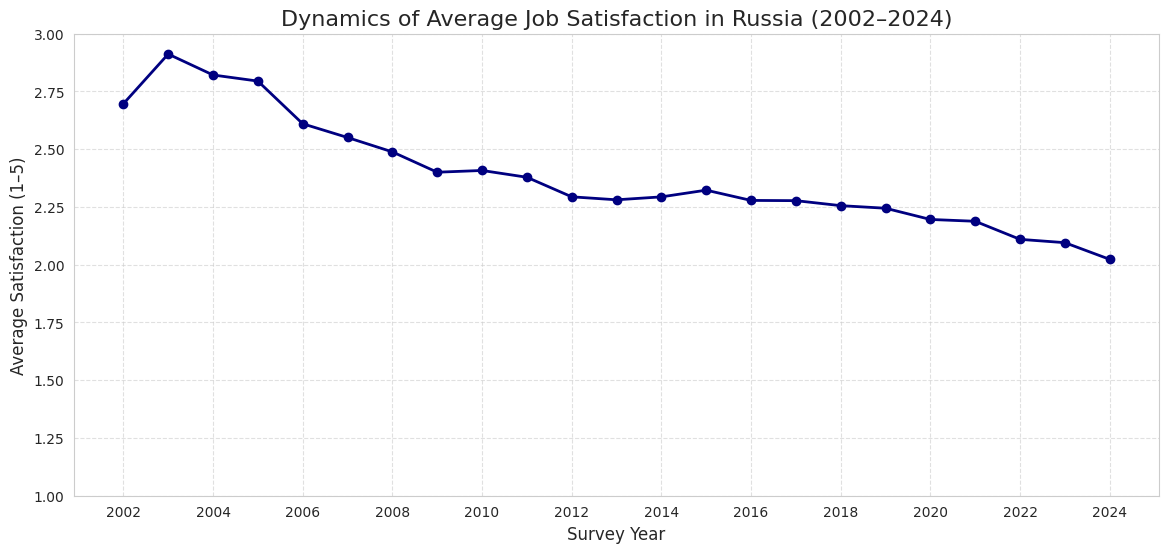

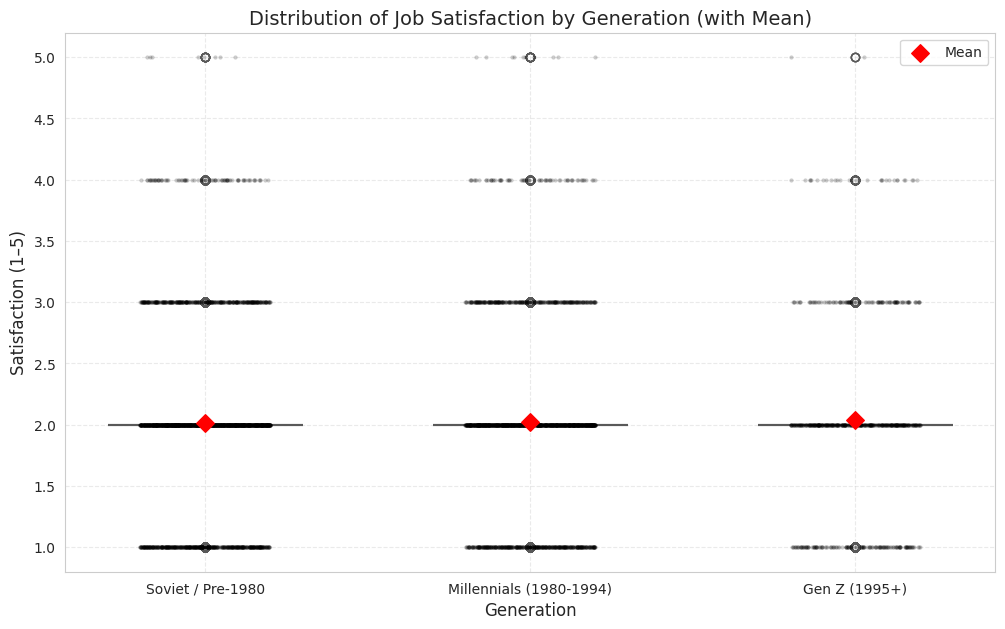

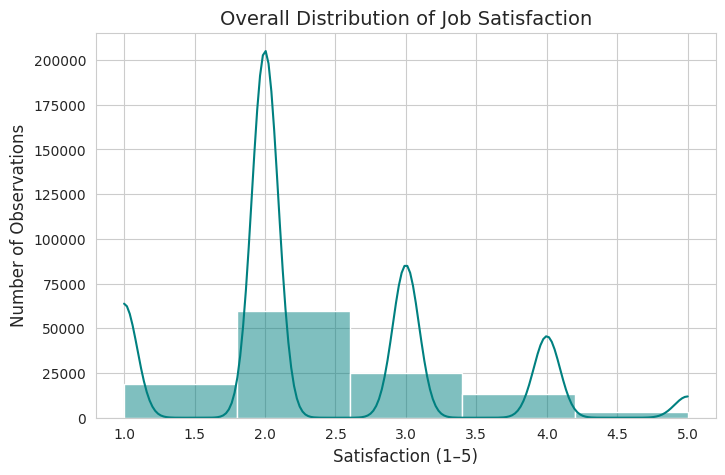

=== Average satisfaction by periods ===
                       mean  count
period                            
Period 1 (2004-2009)  2.644  32869
Period 2 (2010-2019)  2.308  62000
Period 3 (2020-2024)  2.121  25426

=== Average satisfaction by generations ===
                          mean  count
cohort                               
Gen Z (1995+)            2.040    650
Millennials (1980-1994)  2.026   1996
Soviet / Pre-1980        2.015   2415


In [80]:
# Block 4. descriptive statistics and visualization

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. dynamics of average satisfaction by year (2002–2024)
trend = df_model.groupby('year')['job_sat_overall'].mean().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(trend['year'], trend['job_sat_overall'], marker='o', linestyle='-', color='navy', linewidth=2)
plt.title('Dynamics of Average Job Satisfaction in Russia (2002–2024)', fontsize=16)
plt.xlabel('Survey Year', fontsize=12)
plt.ylabel('Average Satisfaction (1–5)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(2002, 2025, 2))  # labels every 2 years
plt.ylim(1.0, 3.0)  # roughly typical range
plt.show()

# 2. improved boxplot: satisfaction distribution by generation with points and mean markers
plt.figure(figsize=(12, 7))

# create a boxplot
ax = sns.boxplot(data=df_model, x='cohort', y='job_sat_overall',
                 order=['Soviet / Pre-1980', 'Millennials (1980-1994)', 'Gen Z (1995+)'],
                 palette='Set2', linewidth=1.5, width=0.6)

# overlay jittered points (alpha for transparency)
sns.stripplot(data=df_model, x='cohort', y='job_sat_overall',
              order=['Soviet / Pre-1980', 'Millennials (1980-1994)', 'Gen Z (1995+)'],
              color='black', alpha=0.2, size=3, jitter=0.2)

# compute and add mean markers (red diamonds)
means = df_model.groupby('cohort')['job_sat_overall'].mean().reindex(
    ['Soviet / Pre-1980', 'Millennials (1980-1994)', 'Gen Z (1995+)']
)
for i, cohort in enumerate(means.index):
    plt.scatter(i, means[cohort], color='red', marker='D', s=80,
                label='Mean' if i==0 else "", zorder=10)

plt.title('Distribution of Job Satisfaction by Generation (with Mean)', fontsize=14)
plt.xlabel('Generation', fontsize=12)
plt.ylabel('Satisfaction (1–5)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# 3. histogram (overall distribution)
plt.figure(figsize=(8, 5))
sns.histplot(df_model['job_sat_overall'], bins=5, kde=True, color='teal')
plt.title('Overall Distribution of Job Satisfaction', fontsize=14)
plt.xlabel('Satisfaction (1–5)', fontsize=12)
plt.ylabel('Number of Observations', fontsize=12)
plt.show()

# 4. average satisfaction by period (table)
print("=== Average satisfaction by periods ===")
print(df_model.groupby('period')['job_sat_overall'].agg(['mean', 'count']).round(3))

# 5. average satisfaction by generation (table)
print("\n=== Average satisfaction by generations ===")
print(df_model.groupby('cohort')['job_sat_overall'].agg(['mean', 'count']).round(3))


--- PCA for cohort: Soviet / Pre-1980 (n=2303) ---
Proportion of explained variance:
  PC1: 0.660
  PC2: 0.143
  Total: 0.803

Loadings (coefficients):
                      PC1    PC2
job_sat_overall     0.535 -0.373
job_sat_conditions  0.523 -0.490
job_sat_pay         0.462  0.756
job_sat_growth      0.476  0.223

--- PCA for cohort: Millennials (1980-1994) (n=1940) ---
Proportion of explained variance:
  PC1: 0.670
  PC2: 0.140
  Total: 0.811

Loadings (coefficients):
                      PC1    PC2
job_sat_overall     0.532 -0.386
job_sat_conditions  0.514 -0.558
job_sat_pay         0.474  0.559
job_sat_growth      0.477  0.477

--- PCA for cohort: Gen Z (1995+) (n=624) ---
Proportion of explained variance:
  PC1: 0.687
  PC2: 0.148
  Total: 0.835

Loadings (coefficients):
                      PC1    PC2
job_sat_overall     0.540 -0.295
job_sat_conditions  0.502 -0.603
job_sat_pay         0.489  0.301
job_sat_growth      0.465  0.677


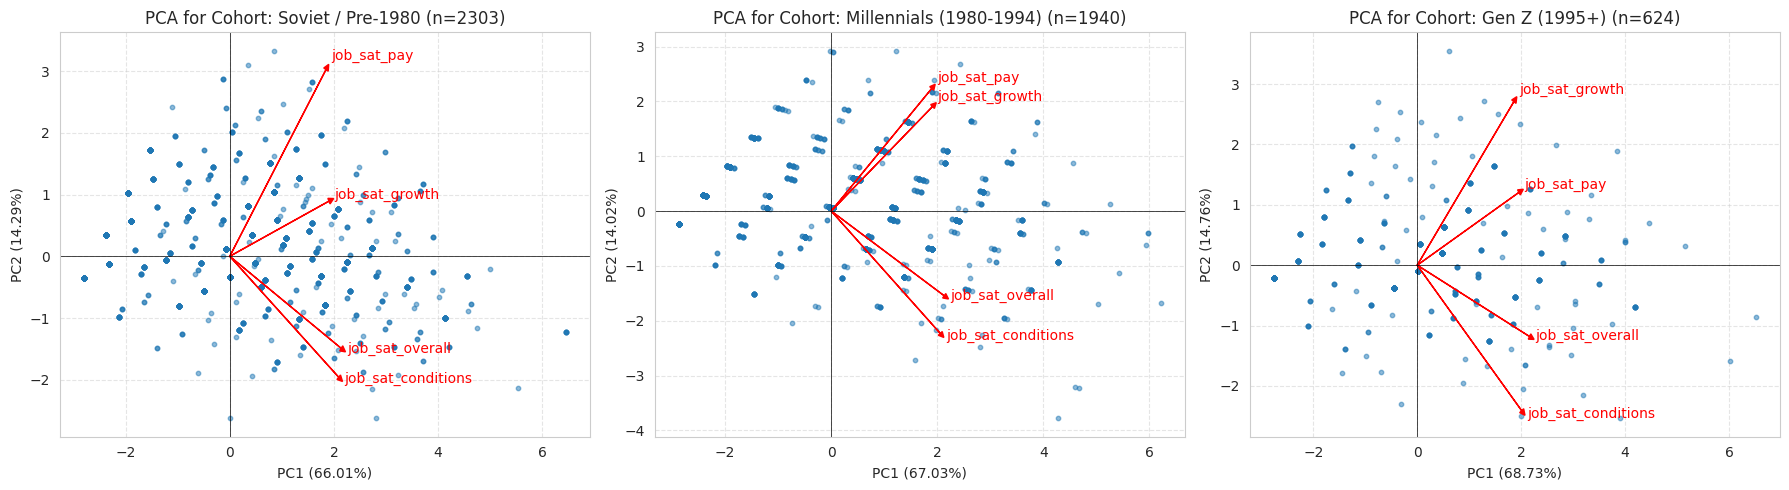

In [81]:
# Block 5. principal component analysis (pca) for each cohort

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ensure the required columns exist
pca_cols = ['job_sat_overall', 'job_sat_conditions', 'job_sat_pay', 'job_sat_growth']
missing = [col for col in pca_cols if col not in df_model.columns]
if missing:
    print(f"Warning: missing columns: {missing}. PCA will be skipped.")
else:
    # dictionary to store pca results
    pca_results = {}

    # iterate over each cohort
    for cohort_name in df_model['cohort'].dropna().unique():
        cohort_data = df_model[df_model['cohort'] == cohort_name]
        # take only complete rows across all 4 variables
        pca_subset = cohort_data[pca_cols].dropna()

        if len(pca_subset) < 10:
            print(f"Cohort {cohort_name}: too few observations ({len(pca_subset)}), skipping.")
            continue

        # standardization
        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(pca_subset)

        # pca with 2 components (for visualization)
        pca = PCA(n_components=2)
        pca.fit(scaled_data)
        scores = pca.transform(scaled_data)

        # store results
        pca_results[cohort_name] = {
            'n': len(pca_subset),
            'explained_variance': pca.explained_variance_ratio_,
            'loadings': pd.DataFrame(pca.components_.T,
                                     index=pca_cols,
                                     columns=['PC1', 'PC2']),
            'scores': scores,
            'scaler': scaler,
            'pca': pca
        }

        # output
        print(f"\n--- PCA for cohort: {cohort_name} (n={len(pca_subset)}) ---")
        print("Proportion of explained variance:")
        print(f"  PC1: {pca.explained_variance_ratio_[0]:.3f}")
        print(f"  PC2: {pca.explained_variance_ratio_[1]:.3f}")
        print(f"  Total: {pca.explained_variance_ratio_.sum():.3f}")
        print("\nLoadings (coefficients):")
        print(pca_results[cohort_name]['loadings'].round(3))

    # visualization: biplot of the first two components for each cohort
    if pca_results:
        fig, axes = plt.subplots(1, len(pca_results), figsize=(6*len(pca_results), 5))
        if len(pca_results) == 1:
            axes = [axes]

        for ax, (cohort_name, res) in zip(axes, pca_results.items()):
            scores = res['scores']
            loadings = res['loadings']
            ax.scatter(scores[:, 0], scores[:, 1], alpha=0.5, s=10)
            ax.set_title(f'PCA for Cohort: {cohort_name} (n={res["n"]})')
            ax.set_xlabel(f'PC1 ({res["explained_variance"][0]:.2%})')
            ax.set_ylabel(f'PC2 ({res["explained_variance"][1]:.2%})')
            # add loading arrows
            for i, var in enumerate(pca_cols):
                ax.arrow(0, 0, loadings.iloc[i, 0]*4, loadings.iloc[i, 1]*4,
                         head_width=0.1, head_length=0.1, fc='red', ec='red')
                ax.text(loadings.iloc[i, 0]*4.2, loadings.iloc[i, 1]*4.2, var, color='red', fontsize=10)
            ax.grid(True, linestyle='--', alpha=0.5)
            ax.axhline(y=0, color='k', linewidth=0.5)
            ax.axvline(x=0, color='k', linewidth=0.5)

        plt.tight_layout()
        plt.show()
    else:
        print("PCA could not be performed for any cohort.")

In [82]:
# Block 6. ordinal logistic regression (with removal of constant columns)

import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("Preparing data for regression...")

# 1. prepare data
df_reg = df_model.copy()

# center age
df_reg['age_c'] = df_reg['age'] - df_reg['age'].mean()

# log salary
if 'salary_30d' in df_reg.columns:
    df_reg['log_salary'] = np.log(df_reg['salary_30d'] + 1)
else:
    df_reg['log_salary'] = np.nan

# gender (male = 1)
df_reg['male'] = (df_reg['gender'] == 1).astype(int)

# higher education
if 'education_highest' in df_reg.columns:
    df_reg['edu_high'] = df_reg['education_highest'].isin([10,11,12,13,14]).astype(int)
else:
    df_reg['edu_high'] = np.nan

# trust in management
if 'trust_management' in df_reg.columns:
    df_reg['trust_man'] = df_reg['trust_management']
else:
    df_reg['trust_man'] = np.nan

# cohort dummies (base = Soviet/Pre-1980)
df_reg['cohort_millennial'] = (df_reg['cohort'] == 'Millennials (1980-1994)').astype(int)
df_reg['cohort_genz'] = (df_reg['cohort'] == 'Gen Z (1995+)').astype(int)

# period dummies (base = Period 1)
df_reg['period2'] = (df_reg['period'] == 'Period 2 (2010-2019)').astype(int)
df_reg['period3'] = (df_reg['period'] == 'Period 3 (2020-2024)').astype(int)

# base set of predictors
base_features = ['age_c', 'male', 'log_salary', 'edu_high', 'trust_man',
                 'cohort_millennial', 'cohort_genz', 'period2', 'period3']

# drop rows with missing values in the dependent variable and predictors
df_clean = df_reg.dropna(subset=['job_sat_overall'] + base_features).copy()
print(f"Sample size after dropping missing values: {len(df_clean)}")

if len(df_clean) < 100:
    print("Too few observations. Exiting.")
    exit()

# 2. function to clean the matrix from constant and linearly dependent columns
from sklearn.preprocessing import StandardScaler

def clean_matrix(X):
    # drop columns with zero variance (constant)
    std = X.std(axis=0)
    constant_cols = std == 0
    if constant_cols.any():
        removed = X.columns[constant_cols].tolist()
        print(f"Dropping constant columns: {removed}")
        X = X.loc[:, ~constant_cols]
    # check for collinearity (drop one from pairs with correlation >0.999)
    corr = X.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > 0.999)]
    if to_drop:
        print(f"Dropping highly correlated columns: {to_drop}")
        X = X.drop(columns=to_drop)
    return X

# 3. model 1: main
print("\n--- Model 1: Main (without interactions) ---")
X1 = df_clean[base_features].copy()
# clean
X1_clean = clean_matrix(X1)
y = df_clean['job_sat_overall'].astype(int)

try:
    model1 = OrderedModel(y, X1_clean, distr='logit')
    result1 = model1.fit(method='bfgs', disp=False)
    print(result1.summary())
    # print significant coefficients
    print("\nSignificant predictors (p < 0.05):")
    for var in result1.params.index:
        if result1.pvalues[var] < 0.05:
            print(f"  {var}: coef = {result1.params[var]:.4f}, p = {result1.pvalues[var]:.4f}")
except Exception as e:
    print(f"Error in model 1: {e}")

# 4. model 2: with interactions
print("\n--- Model 2: With cohort × period interactions ---")
# create interactions
df_clean['millennial_period2'] = df_clean['cohort_millennial'] * df_clean['period2']
df_clean['millennial_period3'] = df_clean['cohort_millennial'] * df_clean['period3']
df_clean['genz_period2'] = df_clean['cohort_genz'] * df_clean['period2']
df_clean['genz_period3'] = df_clean['cohort_genz'] * df_clean['period3']

inter_features = base_features + ['millennial_period2', 'millennial_period3',
                                  'genz_period2', 'genz_period3']
X2 = df_clean[inter_features].copy()
X2_clean = clean_matrix(X2)

try:
    model2 = OrderedModel(y, X2_clean, distr='logit')
    result2 = model2.fit(method='bfgs', disp=False)
    print(result2.summary())
except Exception as e:
    print(f"Error in model 2: {e}")

# 5. model comparison (if both succeeded)
try:
    if 'result1' in locals() and 'result2' in locals():
        print("\n=== Model comparison ===")
        print(f"AIC model 1: {result1.aic:.2f}")
        print(f"AIC model 2: {result2.aic:.2f}")
        lr_stat = -2 * (result1.llf - result2.llf)
        df_diff = len(result2.params) - len(result1.params)
        from scipy.stats import chi2
        p_lr = 1 - chi2.cdf(lr_stat, df_diff)
        print(f"LR test: χ²={lr_stat:.2f}, df={df_diff}, p={p_lr:.4f}")
        if p_lr < 0.05:
            print("The interaction model is significantly better.")
        else:
            print("The interaction model does not provide a significant improvement.")
except Exception as e:
    print(f"Error in comparison: {e}")

print("\nRegression analysis completed.")

Preparing data for regression...
Sample size after dropping missing values: 4138

--- Model 1: Main (without interactions) ---
Dropping constant columns: ['period2', 'period3']
                             OrderedModel Results                             
Dep. Variable:        job_sat_overall   Log-Likelihood:                -3914.0
Model:                   OrderedModel   AIC:                             7850.
Method:            Maximum Likelihood   BIC:                             7920.
Date:                Sun, 28 Jun 2026                                         
Time:                        16:52:34                                         
No. Observations:                4138                                         
Df Residuals:                    4127                                         
Df Model:                           7                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
--------------------------

Regions with n>=30: 40


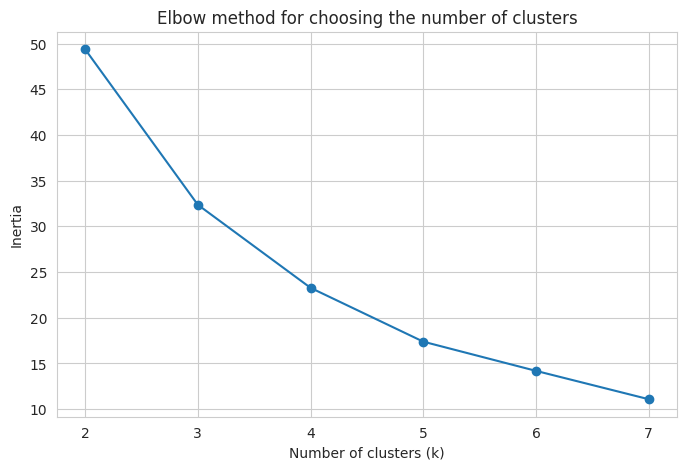


Using k = 3 clusters.

=== Cluster characteristics (original scale: 1 – good, 5 – bad) ===
        sat_mean               sat_std                n_obs
            mean    min    max    mean    min    max    sum
cluster                                                    
0          2.316  2.160  2.423   0.825  0.753  0.890  24567
1          2.235  1.886  2.333   0.992  0.931  1.091  48730
2          2.500  2.386  2.690   1.001  0.921  1.180  46998


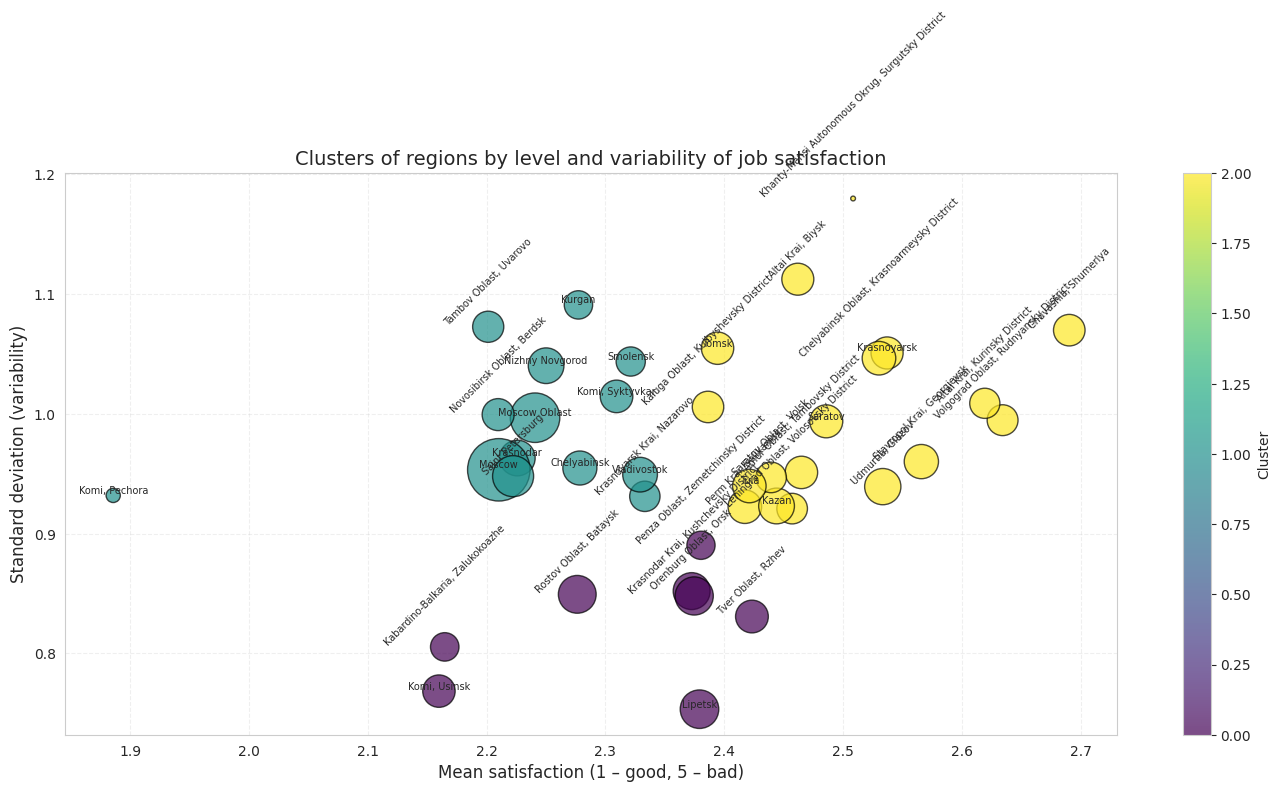


=== Regions by cluster ===
Cluster 0: Orenburg Oblast, Orsk, Tver Oblast, Rzhev, Lipetsk, Kabardino-Balkaria, Zalukokoazhe, Komi, Usinsk, Penza Oblast, Zemetchinsky District, Krasnodar Krai, Kushchevsky District, Rostov Oblast, Bataysk
Cluster 1: Krasnodar, Tambov Oblast, Uvarovo, Kurgan, Krasnoyarsk Krai, Nazarovo, Vladivostok, Komi, Syktyvkar, Chelyabinsk, Nizhny Novgorod, Smolensk, Moscow, Saint Petersburg, Moscow Oblast, Novosibirsk Oblast, Berdsk, Komi, Pechora
Cluster 2: Leningrad Oblast, Volosovsky District, Udmurtia, Glazov, Perm Krai, Solikamsk, Kaluga Oblast, Kuibyshevsky District, Volgograd Oblast, Rudnyansky District, Kazan, Chuvashia, Shumerlya, Stavropol Krai, Georgievsk, Altai Krai, Kurinsky District, Krasnoyarsk, Saratov, Tomsk, Altai Krai, Biysk, Khanty-Mansi Autonomous Okrug, Surgutsky District, Amur Oblast, Tambovsky District, Saratov Oblast, Volsk, Chelyabinsk Oblast, Krasnoarmeysky District, Tula

=== Interpretation of clusters (by mean satisfaction) ===
Cluster 0

In [83]:
# Block 7. clustering of regions by satisfaction level (original scale)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. check if the region column exists
if 'region' not in df_model.columns:
    print("Column 'region' is missing. Clustering is not possible.")
    exit()

# 2. aggregate by region (using original job_sat_overall scale)
region_stats = df_model.groupby('region').agg({
    'job_sat_overall': ['mean', 'std', 'count', 'median']
}).reset_index()
region_stats.columns = ['region', 'sat_mean', 'sat_std', 'n_obs', 'sat_median']

# 3. keep only regions with sufficient observations (>30)
region_stats = region_stats[region_stats['n_obs'] >= 30].copy()
print(f"Regions with n>=30: {len(region_stats)}")

if len(region_stats) < 5:
    print("Too few regions for clustering. Minimum is 5.")
    print(region_stats.sort_values('sat_mean').head(10))
    exit()

# 4. prepare data for clustering (mean + standard deviation)
features = region_stats[['sat_mean', 'sat_std']].copy()
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# 5. determine optimal number of clusters (elbow method)
from sklearn.cluster import KMeans
inertia = []
K_range = range(2, min(8, len(region_stats)))
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow method for choosing the number of clusters')
plt.grid(True)
plt.show()

# 6. fix 3 clusters (as per the research design)
n_clusters = 3
print(f"\nUsing k = {n_clusters} clusters.")

# 7. clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
region_stats['cluster'] = kmeans.fit_predict(scaled_features)

# 8. cluster characteristics
print("\n=== Cluster characteristics (original scale: 1 – good, 5 – bad) ===")
cluster_summary = region_stats.groupby('cluster').agg({
    'sat_mean': ['mean', 'min', 'max'],
    'sat_std': ['mean', 'min', 'max'],
    'n_obs': 'sum'
}).round(3)
print(cluster_summary)

# 9. dictionary of region names (by region codes from your list)
region_names = {
    1: 'Leningrad Oblast, Volosovsky District',
    9: 'Krasnodar',
    10: 'Udmurtia, Glazov',
    12: 'Perm Krai, Solikamsk',
    14: 'Kaluga Oblast, Kuibyshevsky District',
    33: 'Tambov Oblast, Uvarovo',
    39: 'Volgograd Oblast, Rudnyansky District',
    45: 'Kazan',
    46: 'Kurgan',
    47: 'Orenburg Oblast, Orsk',
    48: 'Chuvashia, Shumerlya',
    52: 'Stavropol Krai, Georgievsk',
    58: 'Altai Krai, Kurinsky District',
    66: 'Krasnoyarsk',
    67: 'Tver Oblast, Rzhev',
    70: 'Saratov',
    71: 'Tomsk',
    72: 'Lipetsk',
    73: 'Krasnoyarsk Krai, Nazarovo',
    77: 'Kabardino-Balkaria, Zalukokoazhe',
    84: 'Altai Krai, Biysk',
    86: 'Khanty-Mansi Autonomous Okrug, Surgutsky District',
    89: 'Komi, Usinsk',
    92: 'Vladivostok',
    93: 'Amur Oblast, Tambovsky District',
    100: 'Saratov Oblast, Volsk',
    105: 'Komi, Syktyvkar',
    106: 'Chelyabinsk',
    107: 'Chelyabinsk Oblast, Krasnoarmeysky District',
    116: 'Nizhny Novgorod',
    117: 'Penza Oblast, Zemetchinsky District',
    129: 'Krasnodar Krai, Kushchevsky District',
    135: 'Smolensk',
    136: 'Tula',
    137: 'Rostov Oblast, Bataysk',
    138: 'Moscow',
    141: 'Saint Petersburg',
    142: 'Moscow Oblast',
    161: 'Novosibirsk Oblast, Berdsk',
    200: 'Komi, Pechora'
}

# 10. visualize clusters
plt.figure(figsize=(14, 8))
scatter = plt.scatter(
    region_stats['sat_mean'],
    region_stats['sat_std'],
    c=region_stats['cluster'],
    cmap='viridis',
    s=region_stats['n_obs'] / 5,  # size proportional to number of observations
    alpha=0.7,
    edgecolors='black'
)

# label points (using names from the dictionary)
for i, row in region_stats.iterrows():
    region_code = int(row['region'])
    label = region_names.get(region_code, str(region_code))
    plt.annotate(
        label,
        (row['sat_mean'], row['sat_std']),
        fontsize=7,
        ha='center',
        va='bottom',
        rotation=45 if len(label) > 15 else 0
    )

plt.xlabel('Mean satisfaction (1 – good, 5 – bad)', fontsize=12)
plt.ylabel('Standard deviation (variability)', fontsize=12)
plt.title('Clusters of regions by level and variability of job satisfaction', fontsize=14)
plt.colorbar(scatter, label='Cluster')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# 11. list of regions by cluster (with names)
print("\n=== Regions by cluster ===")
for cluster in sorted(region_stats['cluster'].unique()):
    regions = region_stats[region_stats['cluster'] == cluster]
    codes = regions['region'].astype(int).tolist()
    names = [region_names.get(c, str(c)) for c in codes]
    print(f"Cluster {cluster}: {', '.join(names)}")

# 12. interpretation (with respect to the original scale)
print("\n=== Interpretation of clusters (by mean satisfaction) ===")
for cluster in sorted(region_stats['cluster'].unique()):
    cluster_data = region_stats[region_stats['cluster'] == cluster]
    mean_sat = cluster_data['sat_mean'].mean()
    mean_std = cluster_data['sat_std'].mean()
    # lower mean_sat means better satisfaction
    if mean_sat < 2.8 and mean_std < 0.7:
        print(f"Cluster {cluster}: Low mean (good satisfaction), low variability → 'Affluent regions'")
    elif mean_sat < 2.8 and mean_std >= 0.7:
        print(f"Cluster {cluster}: Low mean (good), high variability → 'Contrasting regions'")
    elif mean_sat >= 2.8 and mean_std < 0.7:
        print(f"Cluster {cluster}: High mean (poor), low variability → 'Consistently disadvantaged'")
    else:
        print(f"Cluster {cluster}: High mean (poor), high variability → 'Problematic with internal contrasts'")


=== Characteristics of 4 clusters (original scale: 1 – good, 5 – bad) ===
          sat_mean               sat_std                n_obs
              mean    min    max    mean    min    max    sum
cluster_4                                                    
0            2.307  2.160  2.423   0.815  0.753  0.852  22501
1            2.219  1.886  2.321   1.001  0.932  1.091  43215
2            2.435  2.329  2.566   0.944  0.890  1.006  36146
3            2.547  2.394  2.690   1.065  0.995  1.180  18433


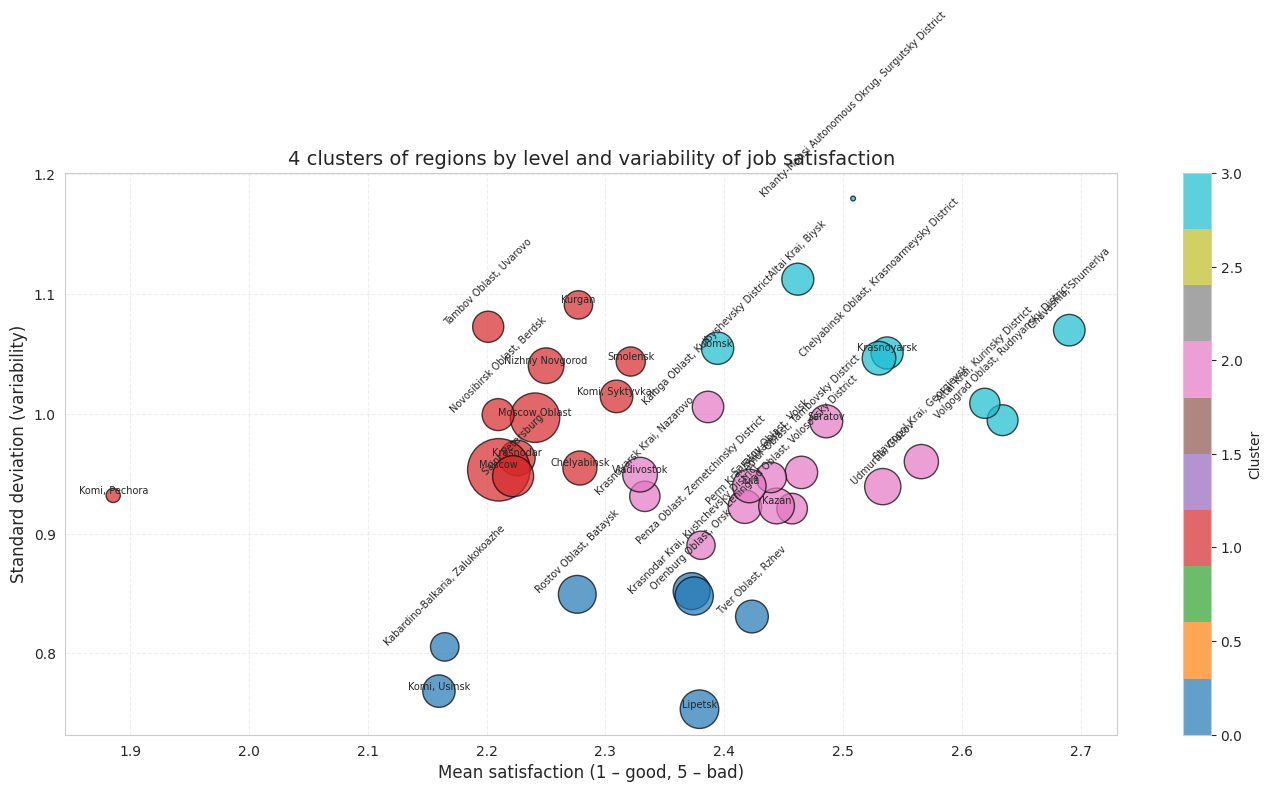


=== Regions by cluster (k=4) ===
Cluster 0 (mean = 2.307):
  Orenburg Oblast, Orsk, Tver Oblast, Rzhev, Lipetsk, Kabardino-Balkaria, Zalukokoazhe, Komi, Usinsk, Krasnodar Krai, Kushchevsky District, Rostov Oblast, Bataysk
Cluster 1 (mean = 2.219):
  Krasnodar, Tambov Oblast, Uvarovo, Kurgan, Komi, Syktyvkar, Chelyabinsk, Nizhny Novgorod, Smolensk, Moscow, Saint Petersburg, Moscow Oblast, Novosibirsk Oblast, Berdsk, Komi, Pechora
Cluster 2 (mean = 2.435):
  Leningrad Oblast, Volosovsky District, Udmurtia, Glazov, Perm Krai, Solikamsk, Kaluga Oblast, Kuibyshevsky District, Kazan, Stavropol Krai, Georgievsk, Saratov, Krasnoyarsk Krai, Nazarovo, Vladivostok, Amur Oblast, Tambovsky District, Saratov Oblast, Volsk, Penza Oblast, Zemetchinsky District, Tula
Cluster 3 (mean = 2.547):
  Volgograd Oblast, Rudnyansky District, Chuvashia, Shumerlya, Altai Krai, Kurinsky District, Krasnoyarsk, Tomsk, Altai Krai, Biysk, Khanty-Mansi Autonomous Okrug, Surgutsky District, Chelyabinsk Oblast, Krasnoar

In [84]:
# Block 8. clustering of regions with 4 clusters

# using the already prepared region_stats from the previous block
# if region_stats is not defined, recalculate it
if 'region_stats' not in locals():
    region_stats = df_model.groupby('region').agg({
        'job_sat_overall': ['mean', 'std', 'count']
    }).reset_index()
    region_stats.columns = ['region', 'sat_mean', 'sat_std', 'n_obs']
    region_stats = region_stats[region_stats['n_obs'] >= 30].copy()

# prepare data
features = region_stats[['sat_mean', 'sat_std']].copy()
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# clustering with k=4
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
region_stats['cluster_4'] = kmeans_4.fit_predict(scaled_features)

# cluster characteristics
print("\n=== Characteristics of 4 clusters (original scale: 1 – good, 5 – bad) ===")
cluster_summary_4 = region_stats.groupby('cluster_4').agg({
    'sat_mean': ['mean', 'min', 'max'],
    'sat_std': ['mean', 'min', 'max'],
    'n_obs': 'sum'
}).round(3)
print(cluster_summary_4)

# visualization
plt.figure(figsize=(14, 8))
scatter = plt.scatter(
    region_stats['sat_mean'],
    region_stats['sat_std'],
    c=region_stats['cluster_4'],
    cmap='tab10',
    s=region_stats['n_obs'] / 5,
    alpha=0.7,
    edgecolors='black'
)

for i, row in region_stats.iterrows():
    region_code = int(row['region'])
    label = region_names.get(region_code, str(region_code))
    plt.annotate(
        label,
        (row['sat_mean'], row['sat_std']),
        fontsize=7,
        ha='center',
        va='bottom',
        rotation=45 if len(label) > 15 else 0
    )

plt.xlabel('Mean satisfaction (1 – good, 5 – bad)', fontsize=12)
plt.ylabel('Standard deviation (variability)', fontsize=12)
plt.title('4 clusters of regions by level and variability of job satisfaction', fontsize=14)
plt.colorbar(scatter, label='Cluster')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# lists of regions by cluster
print("\n=== Regions by cluster (k=4) ===")
for cluster in sorted(region_stats['cluster_4'].unique()):
    regions = region_stats[region_stats['cluster_4'] == cluster]
    codes = regions['region'].astype(int).tolist()
    names = [region_names.get(c, str(c)) for c in codes]
    print(f"Cluster {cluster} (mean = {regions['sat_mean'].mean():.3f}):")
    print(f"  {', '.join(names)}")

# interpretation (based on mean values)
print("\n=== Interpretation of clusters (by mean satisfaction) ===")
for cluster in sorted(region_stats['cluster_4'].unique()):
    cluster_data = region_stats[region_stats['cluster_4'] == cluster]
    mean_sat = cluster_data['sat_mean'].mean()
    mean_std = cluster_data['sat_std'].mean()
    if mean_sat < 2.8 and mean_std < 0.7:
        print(f"Cluster {cluster}: Low mean (good) + low variability → 'Affluent and stable'")
    elif mean_sat < 2.8 and mean_std >= 0.7:
        print(f"Cluster {cluster}: Low mean (good) + high variability → 'Affluent but contrasting'")
    elif mean_sat >= 2.8 and mean_std < 0.7:
        print(f"Cluster {cluster}: High mean (poor) + low variability → 'Consistently disadvantaged'")
    else:
        print(f"Cluster {cluster}: High mean (poor) + high variability → 'Problematic with internal contrasts'")

Regions with n>=30: 40

=== Cluster characteristics (based on median and iqr) ===
        sat_median            iqr             n_obs
              mean  min  max mean  min  max     sum
cluster                                            
0              2.0  2.0  2.0  1.0  1.0  1.0  110856
1              2.0  2.0  2.0  0.0  0.0  0.0    4833
2              2.0  2.0  2.0  2.0  2.0  2.0    4606


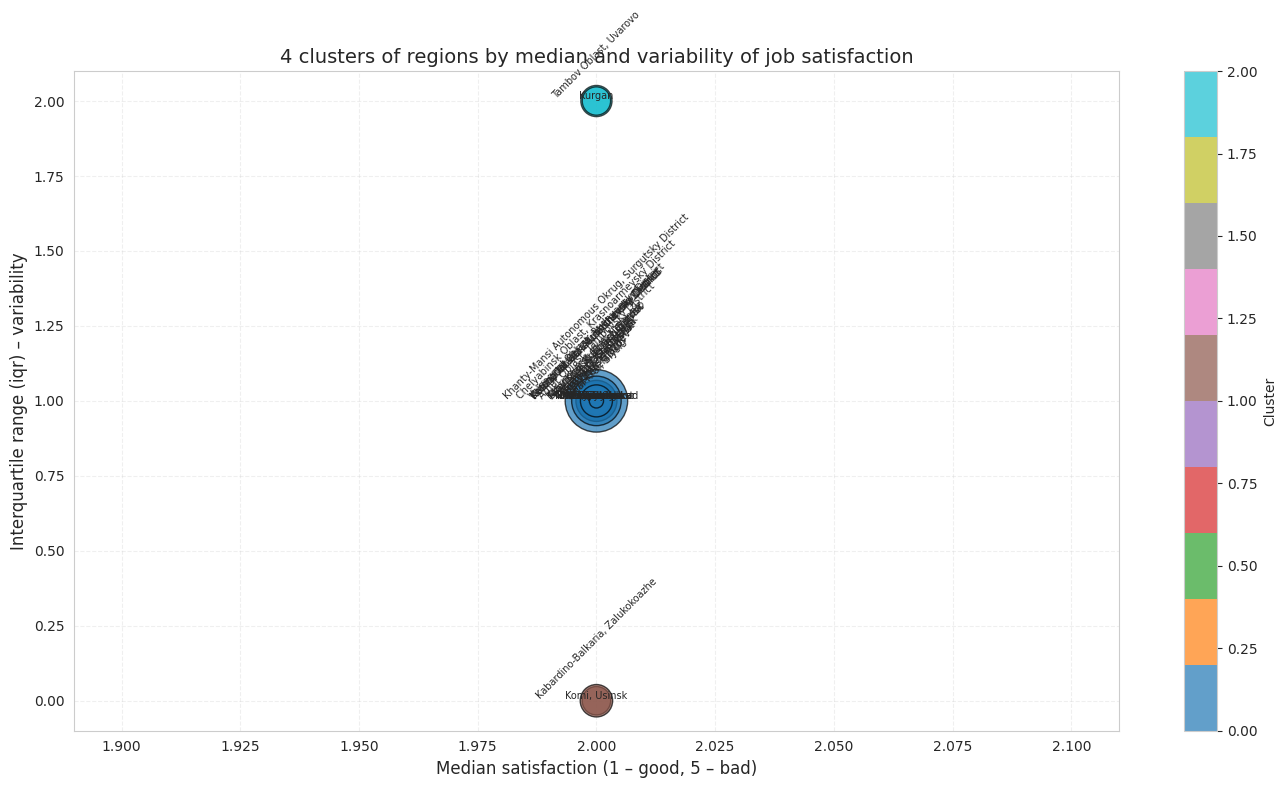


=== Regions by cluster (median + iqr) ===
Cluster 0 (median = 2.000, iqr = 1.000):
  Leningrad Oblast, Volosovsky District, Krasnodar, Udmurtia, Glazov, Perm Krai, Solikamsk, Kaluga Oblast, Kuibyshevsky District, Volgograd Oblast, Rudnyansky District, Kazan, Orenburg Oblast, Orsk, Chuvashia, Shumerlya, Stavropol Krai, Georgievsk, Altai Krai, Kurinsky District, Krasnoyarsk, Tver Oblast, Rzhev, Saratov, Tomsk, Lipetsk, Krasnoyarsk Krai, Nazarovo, Altai Krai, Biysk, Khanty-Mansi Autonomous Okrug, Surgutsky District, Vladivostok, Amur Oblast, Tambovsky District, Saratov Oblast, Volsk, Komi, Syktyvkar, Chelyabinsk, Chelyabinsk Oblast, Krasnoarmeysky District, Nizhny Novgorod, Penza Oblast, Zemetchinsky District, Krasnodar Krai, Kushchevsky District, Smolensk, Tula, Rostov Oblast, Bataysk, Moscow, Saint Petersburg, Moscow Oblast, Novosibirsk Oblast, Berdsk, Komi, Pechora
Cluster 1 (median = 2.000, iqr = 0.000):
  Kabardino-Balkaria, Zalukokoazhe, Komi, Usinsk
Cluster 2 (median = 2.000, iqr 

In [85]:
# Block 9. clustering by median and iqr

# recalculate regional statistics (median, q1, q3, iqr)
region_stats_robust = df_model.groupby('region').agg({
    'job_sat_overall': [
        'median',           # median
        lambda x: x.quantile(0.25),  # q1
        lambda x: x.quantile(0.75),  # q3
        'count'
    ]
}).reset_index()
region_stats_robust.columns = ['region', 'sat_median', 'q1', 'q3', 'n_obs']
region_stats_robust['iqr'] = region_stats_robust['q3'] - region_stats_robust['q1']

# keep regions with n>=30
region_stats_robust = region_stats_robust[region_stats_robust['n_obs'] >= 30].copy()
print(f"Regions with n>=30: {len(region_stats_robust)}")

# prepare data for clustering (median + iqr)
features_robust = region_stats_robust[['sat_median', 'iqr']].copy()
scaler_robust = StandardScaler()
scaled_robust = scaler_robust.fit_transform(features_robust)

# clustering with k=4
kmeans_robust = KMeans(n_clusters=4, random_state=42, n_init=10)
region_stats_robust['cluster'] = kmeans_robust.fit_predict(scaled_robust)

# cluster characteristics
print("\n=== Cluster characteristics (based on median and iqr) ===")
cluster_summary_robust = region_stats_robust.groupby('cluster').agg({
    'sat_median': ['mean', 'min', 'max'],
    'iqr': ['mean', 'min', 'max'],
    'n_obs': 'sum'
}).round(3)
print(cluster_summary_robust)

# visualization
plt.figure(figsize=(14, 8))
scatter = plt.scatter(
    region_stats_robust['sat_median'],
    region_stats_robust['iqr'],
    c=region_stats_robust['cluster'],
    cmap='tab10',
    s=region_stats_robust['n_obs'] / 5,
    alpha=0.7,
    edgecolors='black'
)

for i, row in region_stats_robust.iterrows():
    region_code = int(row['region'])
    label = region_names.get(region_code, str(region_code))
    plt.annotate(
        label,
        (row['sat_median'], row['iqr']),
        fontsize=7,
        ha='center',
        va='bottom',
        rotation=45 if len(label) > 15 else 0
    )

plt.xlabel('Median satisfaction (1 – good, 5 – bad)', fontsize=12)
plt.ylabel('Interquartile range (iqr) – variability', fontsize=12)
plt.title('4 clusters of regions by median and variability of job satisfaction', fontsize=14)
plt.colorbar(scatter, label='Cluster')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# lists of regions by cluster
print("\n=== Regions by cluster (median + iqr) ===")
for cluster in sorted(region_stats_robust['cluster'].unique()):
    regions = region_stats_robust[region_stats_robust['cluster'] == cluster]
    codes = regions['region'].astype(int).tolist()
    names = [region_names.get(c, str(c)) for c in codes]
    print(f"Cluster {cluster} (median = {regions['sat_median'].mean():.3f}, iqr = {regions['iqr'].mean():.3f}):")
    print(f"  {', '.join(names)}")

# interpretation
print("\n=== Interpretation of clusters ===")
for cluster in sorted(region_stats_robust['cluster'].unique()):
    cluster_data = region_stats_robust[region_stats_robust['cluster'] == cluster]
    med = cluster_data['sat_median'].mean()
    iqr = cluster_data['iqr'].mean()
    if med < 2.8 and iqr < 0.8:
        print(f"Cluster {cluster}: Low median (good) + small spread → 'Consistently affluent'")
    elif med < 2.8 and iqr >= 0.8:
        print(f"Cluster {cluster}: Low median (good) + large spread → 'Affluent but polarized'")
    elif med >= 2.8 and iqr < 0.8:
        print(f"Cluster {cluster}: High median (poor) + small spread → 'Consistently disadvantaged'")
    else:
        print(f"Cluster {cluster}: High median (poor) + large spread → 'Problematic with contrasts'")

In [86]:
# Block 10. map of russian regions (fixed)

import plotly.express as px
import plotly.graph_objects as go
import json
import requests
import pandas as pd
import numpy as np

# 1. create the region name dictionary (if not already present)
if 'region_names' not in locals():
    region_names = {
        1: 'Leningrad Oblast, Volosovsky District',
        9: 'Krasnodar',
        10: 'Udmurtia, Glazov',
        12: 'Perm Krai, Solikamsk',
        14: 'Kaluga Oblast, Kuibyshevsky District',
        33: 'Tambov Oblast, Uvarovo',
        39: 'Volgograd Oblast, Rudnyansky District',
        45: 'Kazan',
        46: 'Kurgan',
        47: 'Orenburg Oblast, Orsk',
        48: 'Chuvashia, Shumerlya',
        52: 'Stavropol Krai, Georgievsk',
        58: 'Altai Krai, Kurinsky District',
        66: 'Krasnoyarsk',
        67: 'Tver Oblast, Rzhev',
        70: 'Saratov',
        71: 'Tomsk',
        72: 'Lipetsk',
        73: 'Krasnoyarsk Krai, Nazarovo',
        77: 'Kabardino-Balkaria, Zalukokoazhe',
        84: 'Altai Krai, Biysk',
        86: 'Khanty-Mansi Autonomous Okrug, Surgutsky District',
        89: 'Komi, Usinsk',
        92: 'Vladivostok',
        93: 'Amur Oblast, Tambovsky District',
        100: 'Saratov Oblast, Volsk',
        105: 'Komi, Syktyvkar',
        106: 'Chelyabinsk',
        107: 'Chelyabinsk Oblast, Krasnoarmeysky District',
        116: 'Nizhny Novgorod',
        117: 'Penza Oblast, Zemetchinsky District',
        129: 'Krasnodar Krai, Kushchevsky District',
        135: 'Smolensk',
        136: 'Tula',
        137: 'Rostov Oblast, Bataysk',
        138: 'Moscow',
        141: 'Saint Petersburg',
        142: 'Moscow Oblast',
        161: 'Novosibirsk Oblast, Berdsk',
        200: 'Komi, Pechora'
    }

# 2. load geojson (multiple sources)
geojson_urls = [
    'https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/ru.geojson',
    'https://raw.githubusercontent.com/holtzy/D3-graph-gallery/master/DATA/russia_region.geojson',
    'https://cdn.jsdelivr.net/npm/russia-map/dist/russia.json'
]

geojson_data = None
for url in geojson_urls:
    try:
        print(f"Attempting to load: {url}")
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            geojson_data = response.json()
            print("Successfully loaded!")
            break
        else:
            print(f"HTTP error {response.status_code}")
    except Exception as e:
        print(f"Error: {e}")

if geojson_data is None:
    print("Failed to load GeoJSON automatically.")
    print("You can manually download the file from https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/ru.geojson")
    print("and upload it to Colab, then specify the file path.")
    # alternative: create a point map (without borders) – see below
    use_point_map = True
else:
    use_point_map = False

# 3. prepare data
# use region_stats (if not present, compute it)
if 'region_stats' not in locals():
    region_stats = df_model.groupby('region').agg({
        'job_sat_overall': ['mean', 'count']
    }).reset_index()
    region_stats.columns = ['region', 'sat_mean', 'n_obs']
    region_stats = region_stats[region_stats['n_obs'] >= 30].copy()

region_stats['region_name'] = region_stats['region'].map(region_names)

# extract the federal subject from the name (first part before comma)
def extract_subject(name):
    if pd.isna(name):
        return np.nan
    parts = name.split(',')
    subject = parts[0].strip()
    # adjust common abbreviations
    subject = subject.replace('обл.', 'oblast').replace('край', 'krai')
    subject = subject.replace('респ.', 'republic').replace('р-н', 'district')
    if 'Moscow' in subject:
        subject = 'Moscow'
    if 'Saint Petersburg' in subject:
        subject = 'Saint Petersburg'
    return subject

region_stats['subject'] = region_stats['region_name'].apply(extract_subject)

# aggregate by subject
subject_stats = region_stats.groupby('subject').agg({
    'sat_mean': 'mean',
    'n_obs': 'sum'
}).reset_index()
subject_stats['sat_mean'] = subject_stats['sat_mean'].round(3)

# 4. build the map
if not use_point_map and geojson_data is not None:
    # extract names from GeoJSON
    geo_names = []
    # structure may differ – try both options
    if 'objects' in geojson_data and 'default' in geojson_data['objects']:
        features = geojson_data['objects']['default']['geometries']
    elif 'features' in geojson_data:
        features = geojson_data['features']
    else:
        features = []

    for feature in features:
        props = feature.get('properties', {})
        # look for a name key
        name = props.get('name') or props.get('NAME') or props.get('admin') or props.get('region')
        if name:
            geo_names.append(name)

    print("\nSample names from GeoJSON:", geo_names[:10])

    # matching function (partial match)
    def match_subject(row_subject):
        best = None
        for gname in geo_names:
            if gname and (gname.lower() in row_subject.lower() or row_subject.lower() in gname.lower()):
                best = gname
                break
        return best

    subject_stats['geo_name'] = subject_stats['subject'].apply(match_subject)
    subject_stats_geo = subject_stats.dropna(subset=['geo_name']).copy()

    if len(subject_stats_geo) > 5:
        # build choropleth
        fig = px.choropleth(
            subject_stats_geo,
            geojson=geojson_data,
            locations='geo_name',
            featureidkey="properties.name",  # may differ; try different keys
            color='sat_mean',
            color_continuous_scale='RdYlGn_r',
            range_color=[subject_stats_geo['sat_mean'].min(), subject_stats_geo['sat_mean'].max()],
            scope='europe',
            labels={'sat_mean': 'Mean satisfaction (1–5)'},
            title='Mean job satisfaction across Russian regions (2002–2024)<br>1 – fully satisfied, 5 – not satisfied at all',
            hover_data={'geo_name': True, 'sat_mean': ':.3f', 'n_obs': True}
        )
        fig.update_geos(showcountries=False, showcoastlines=True, showland=True, landcolor='lightgray')
        fig.update_layout(height=700, margin={"r":0,"t":50,"l":0,"b":0})
        fig.show()
    else:
        print("Too few subjects matched. Switching to point map.")
        use_point_map = True

# 5. alternative: point map (if choropleth failed)
if use_point_map:
    print("\nBuilding a point map with markers for region centers.")
    # approximate coordinates for region centers (latitude, longitude) – need manual input.
    # For simplicity, we only use regions that were matched,
    # and add coordinates from an external list or approximate.
    # Create a coordinate dictionary for major subjects (approximate):
    coords = {
        'Moscow': (55.7558, 37.6173),
        'Saint Petersburg': (59.9343, 30.3351),
        'Leningrad Oblast': (60.0, 31.0),
        'Moscow Oblast': (55.7, 37.5),
        'Krasnodar Krai': (45.0, 39.0),
        'Republic of Tatarstan': (55.5, 50.0),
        'Sverdlovsk Oblast': (56.8, 60.6),
        # ... add more if needed
    }
    # for regions not in coords, use the center of Russia (55, 55)
    subject_stats['lat'] = subject_stats['subject'].apply(
        lambda x: coords.get(x, (55.0, 55.0))[0] if x in coords else 55.0
    )
    subject_stats['lon'] = subject_stats['subject'].apply(
        lambda x: coords.get(x, (55.0, 55.0))[1] if x in coords else 55.0
    )

    fig = px.scatter_geo(
        subject_stats,
        lat='lat',
        lon='lon',
        color='sat_mean',
        hover_name='subject',
        hover_data={'sat_mean': ':.3f', 'n_obs': True},
        color_continuous_scale='RdYlGn_r',
        title='Mean job satisfaction by region (point map)',
        labels={'sat_mean': 'Mean satisfaction (1–5)'},
        scope='europe'
    )
    fig.update_geos(showcountries=False, showcoastlines=True, showland=True, landcolor='lightgray')
    fig.update_layout(height=700)
    fig.show()

Attempting to load: https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/ru.geojson
HTTP error 404
Attempting to load: https://raw.githubusercontent.com/holtzy/D3-graph-gallery/master/DATA/russia_region.geojson
HTTP error 404
Attempting to load: https://cdn.jsdelivr.net/npm/russia-map/dist/russia.json
HTTP error 404
Failed to load GeoJSON automatically.
You can manually download the file from https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/ru.geojson
and upload it to Colab, then specify the file path.

Building a point map with markers for region centers.


In [87]:
# Block 11. 3d plot: year, region, mean satisfaction

import plotly.express as px
import pandas as pd
import numpy as np

# 1. aggregate data by year and region
df_3d = df_model.groupby(['year', 'region']).agg(
    mean_sat=('job_sat_overall', 'mean'),
    n_obs=('job_sat_overall', 'count')
).reset_index()

# 2. add region names
df_3d['region_name'] = df_3d['region'].map(region_names)

# 3. drop rows with missing names
df_3d = df_3d.dropna(subset=['region_name'])

# 4. build 3d scatter plot
fig = px.scatter_3d(
    df_3d,
    x='year',
    y='mean_sat',
    z='region_name',
    color='mean_sat',
    size='n_obs',               # point size proportional to number of observations
    hover_name='region_name',
    hover_data={'year': True, 'mean_sat': ':.2f', 'n_obs': True},
    color_continuous_scale='RdYlGn_r',
    title='Mean Job Satisfaction by Year and Region (2002–2024)',
    labels={'year': 'Year', 'mean_sat': 'Mean satisfaction (1–5)', 'region_name': 'Region'}
)

fig.update_layout(
    scene=dict(
        xaxis_title='Year',
        yaxis_title='Mean Satisfaction (1 – good, 5 – bad)',
        zaxis_title='Region',
        zaxis=dict(tickangle=-45)   # rotate region labels for readability
    ),
    height=800,
    width=1000
)

fig.show()

In [88]:
# Block 11c. 3d plot with lines for each region

import plotly.graph_objects as go
import pandas as pd
import numpy as np

# 1. prepare data: mean by year and region
df_line = df_model.groupby(['year', 'region']).agg(
    mean_sat=('job_sat_overall', 'mean'),
    n_obs=('job_sat_overall', 'count')
).reset_index()

# 2. add region names
df_line['region_name'] = df_line['region'].map(region_names)
df_line = df_line.dropna(subset=['region_name'])

# 3. keep only regions with sufficient total observations (>100)
regions_keep = df_line.groupby('region')['n_obs'].sum()
regions_keep = regions_keep[regions_keep >= 100].index
df_line = df_line[df_line['region'].isin(regions_keep)]

# 4. sort by year
df_line = df_line.sort_values(['region', 'year'])

# 5. create figure
fig = go.Figure()

# 6. for each region add a line with markers
for region_id in df_line['region'].unique():
    subset = df_line[df_line['region'] == region_id]
    region_name = subset['region_name'].iloc[0]
    fig.add_trace(go.Scatter3d(
        x=subset['year'],
        y=subset['mean_sat'],
        z=[region_name] * len(subset),  # all points at the same region height
        mode='lines+markers',
        name=region_name,
        line=dict(width=2),
        marker=dict(size=4),
        hovertemplate=f'<b>{region_name}</b><br>Year: %{{x}}<br>Mean satisfaction: %{{y:.2f}}<extra></extra>'
    ))

# 7. layout settings
fig.update_layout(
    scene=dict(
        xaxis_title='Year',
        yaxis_title='Mean satisfaction (1 – good, 5 – bad)',
        zaxis_title='Region',
        zaxis=dict(tickangle=-45, tickfont=dict(size=8))
    ),
    height=800,
    width=1000,
    title='Dynamics of mean job satisfaction by region (2002–2024)'
)

fig.show()

In [89]:
# Block 12. heatmap: year × region × mean satisfaction

import plotly.express as px
import pandas as pd
import numpy as np

# 1. prepare data: mean by year and region
df_heat = df_model.groupby(['year', 'region']).agg(
    mean_sat=('job_sat_overall', 'mean'),
    n_obs=('job_sat_overall', 'count')
).reset_index()

# 2. add region names
df_heat['region_name'] = df_heat['region'].map(region_names)
df_heat = df_heat.dropna(subset=['region_name'])

# 3. keep only regions with sufficient total observations (>100)
regions_keep = df_heat.groupby('region')['n_obs'].sum()
regions_keep = regions_keep[regions_keep >= 100].index
df_heat = df_heat[df_heat['region'].isin(regions_keep)]

# 4. create a pivot table: rows = regions, columns = years, values = mean satisfaction
pivot = df_heat.pivot(index='region_name', columns='year', values='mean_sat')

# 5. sort regions by their average value (optional, for ordering)
pivot['mean'] = pivot.mean(axis=1)
pivot = pivot.sort_values('mean', ascending=False)
pivot = pivot.drop('mean', axis=1)

# 6. draw the heatmap
fig = px.imshow(
    pivot,
    labels=dict(x='Year', y='Region', color='Mean satisfaction (1–5)'),
    title='Mean Job Satisfaction by Year and Region (2002–2024)<br>1 – good, 5 – bad',
    color_continuous_scale='RdYlGn_r',
    aspect='auto',
    text_auto='.2f'  # shows values in cells with two decimal places
)

fig.update_layout(
    height=800,
    width=1000,
    xaxis=dict(title='Year', tickangle=45),
    yaxis=dict(title='Region', tickfont=dict(size=10))
)

fig.show()

In [90]:
# Block 13. heatmap of latest average job satisfaction with generation facets

df_heat_cohort = df_model.groupby(['year', 'region', 'cohort']).agg(
    mean_sat=('job_sat_overall', 'mean'),
    n_obs=('job_sat_overall', 'count')
).reset_index()

df_heat_cohort['region_name'] = df_heat_cohort['region'].map(region_names)
df_heat_cohort = df_heat_cohort.dropna(subset=['region_name'])

# keep only regions with total n_obs >= 100
regions_keep = df_heat_cohort.groupby('region')['n_obs'].sum()
regions_keep = regions_keep[regions_keep >= 100].index
df_heat_cohort = df_heat_cohort[df_heat_cohort['region'].isin(regions_keep)]

# drop NaN in cohort
df_heat_cohort = df_heat_cohort.dropna(subset=['cohort'])

# build separate heatmaps for each generation
for cohort in df_heat_cohort['cohort'].unique():
    subset = df_heat_cohort[df_heat_cohort['cohort'] == cohort]
    pivot = subset.pivot(index='region_name', columns='year', values='mean_sat')
    fig = px.imshow(
        pivot,
        labels=dict(y='Region', color='Mean satisfaction'),
        title=f'Mean satisfaction by region – {cohort}',
        color_continuous_scale='RdYlGn_r',
        aspect='auto',
        text_auto='.2f'
    )
    fig.update_layout(height=500, width=800, xaxis=dict(tickangle=-45))
    fig.show()

In [91]:
# Block 15. data preparation: selecting work-related variables

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. ensure df_model exists
if 'df_model' not in locals():
    print("Loading df_model...")
    try:
        df_model = pd.read_csv('/content/drive/MyDrive/RLMS_clean_with_cohorts.csv')
    except:
        print("Error: df_model not found. Run blocks 3-5 first.")
        raise

# 2. select work-related variables (from the J block and related)
work_vars = [
    'job_sat_overall',        # dependent variable
    'job_sat_conditions',     # satisfaction with conditions
    'job_sat_pay',            # satisfaction with pay
    'job_sat_growth',         # satisfaction with growth
    'salary_30d',             # salary for 30 days
    'log_salary',             # log salary (created earlier)
    'trust_management',       # trust in management
    'trust_colleagues',       # trust in colleagues
    'job_loss_worry',         # worry about job loss
    'find_work_confidence',   # confidence in finding a job
    'has_subordinates',       # having subordinates
    'official_employment',    # official employment
    'firm_size',              # firm size
    'industry',               # industry (code)
    'occupation_isco',        # occupation (isco code)
    'education_highest',      # education level
    'age',                    # age
    'male',                   # gender (created earlier)
    'cohort',                 # generation
    'period'                  # period
]

# 3. create a copy with only these variables
df_work = df_model[work_vars].copy()

# 4. convert categorical variables to factor type (for visualization)
df_work['has_subordinates'] = df_work['has_subordinates'].astype('category')
df_work['official_employment'] = df_work['official_employment'].astype('category')
df_work['cohort'] = df_work['cohort'].astype('category')
df_work['period'] = df_work['period'].astype('category')

# 5. clean obvious outliers (salary > 0)
df_work = df_work[df_work['salary_30d'] > 0]

print(f"Sample size after cleaning: {len(df_work)}")
print("Available variables:", df_work.columns.tolist())

Sample size after cleaning: 109957
Available variables: ['job_sat_overall', 'job_sat_conditions', 'job_sat_pay', 'job_sat_growth', 'salary_30d', 'log_salary', 'trust_management', 'trust_colleagues', 'job_loss_worry', 'find_work_confidence', 'has_subordinates', 'official_employment', 'firm_size', 'industry', 'occupation_isco', 'education_highest', 'age', 'male', 'cohort', 'period']


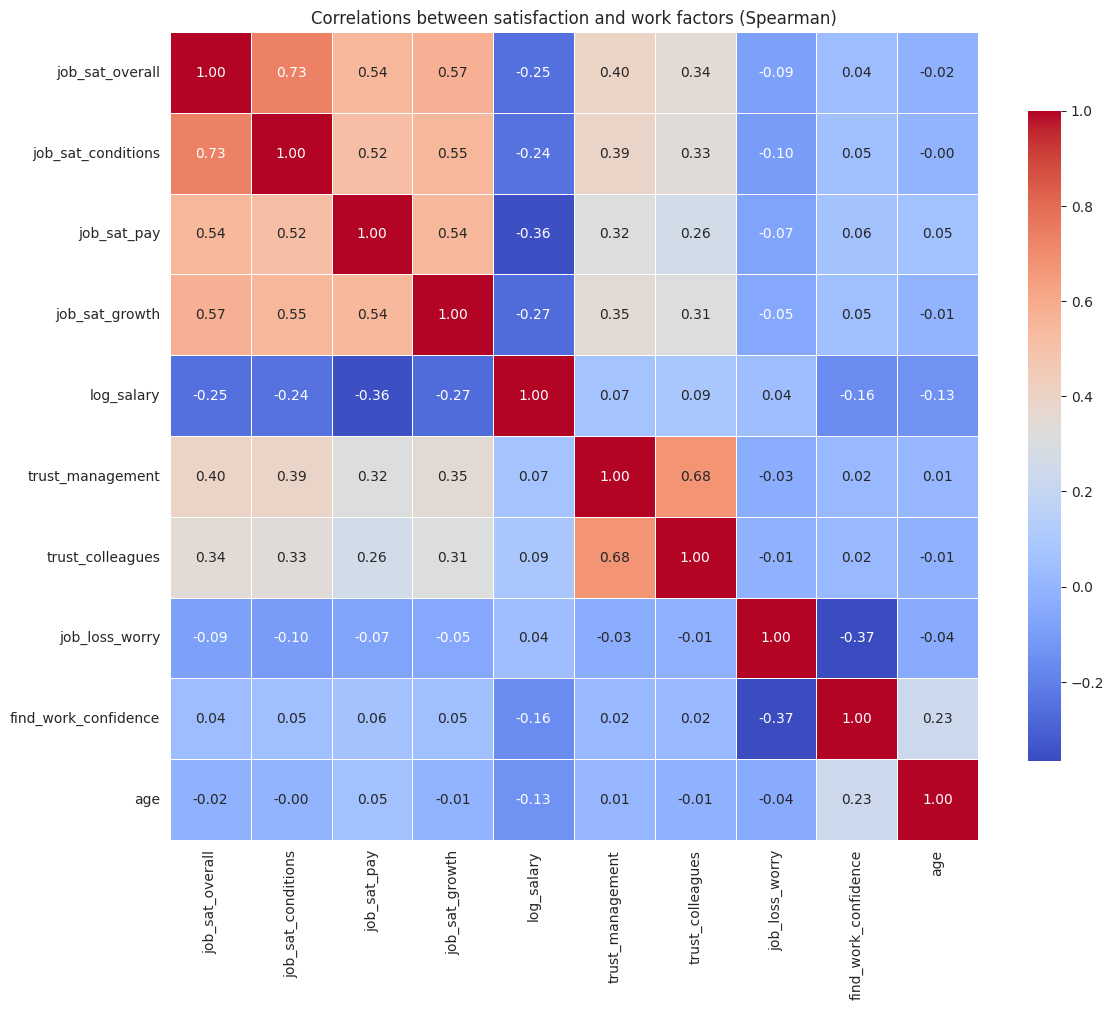


Correlations with overall satisfaction:
job_sat_overall         1.000000
job_sat_conditions      0.734616
job_sat_growth          0.574177
job_sat_pay             0.542175
trust_management        0.400268
trust_colleagues        0.344221
find_work_confidence    0.036535
age                    -0.018827
job_loss_worry         -0.085652
log_salary             -0.252481
Name: job_sat_overall, dtype: float64


In [92]:
# Block 16. correlation matrix for work-related variables

# 1. select numeric variables for correlation
numeric_vars = ['job_sat_overall', 'job_sat_conditions', 'job_sat_pay', 'job_sat_growth',
                'log_salary', 'trust_management', 'trust_colleagues', 'job_loss_worry',
                'find_work_confidence', 'age']

# 2. compute correlation
corr_matrix = df_work[numeric_vars].corr(method='spearman')  # spearman for ordinal variables

# 3. heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlations between satisfaction and work factors (Spearman)')
plt.tight_layout()
plt.show()

# 4. separately: correlations with job_sat_overall
corr_with_sat = corr_matrix['job_sat_overall'].sort_values(ascending=False)
print("\nCorrelations with overall satisfaction:")
print(corr_with_sat)

Dropped 105907 rows with missing values or inf.
X shape: (4050, 14), y shape: (4050,)
Data types in X:
 float64    14
Name: count, dtype: int64
                             OrderedModel Results                             
Dep. Variable:        job_sat_overall   Log-Likelihood:                -3783.3
Model:                   OrderedModel   AIC:                             7603.
Method:            Maximum Likelihood   BIC:                             7716.
Date:                Sun, 28 Jun 2026                                         
Time:                        16:52:42                                         
No. Observations:                4050                                         
Df Residuals:                    4032                                         
Df Model:                          14                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------

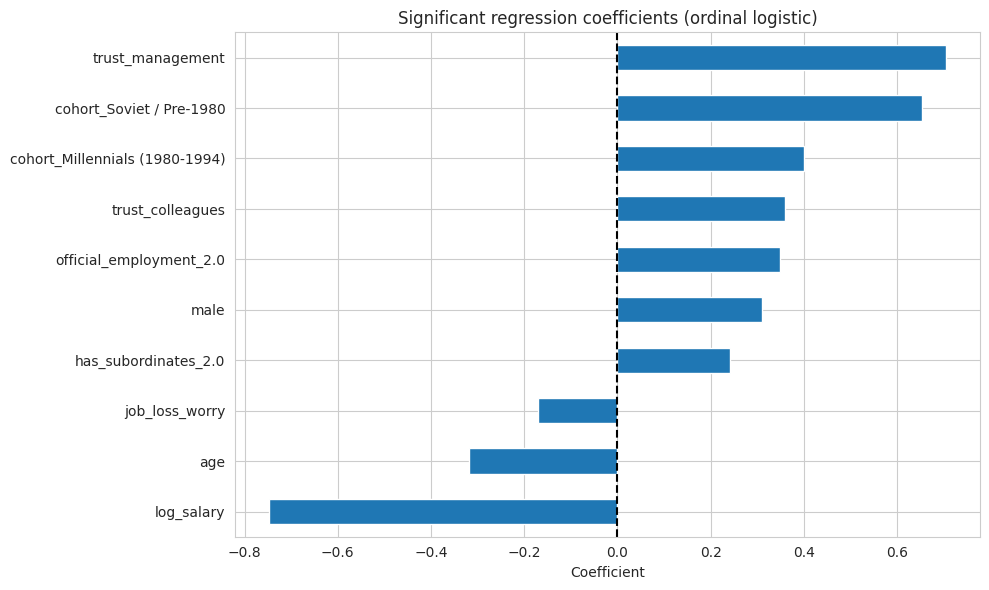

In [93]:
# Block 17. extended ordinal logistic regression (with cleaning of inf/nan)

import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 1. prepare data
df_reg2 = df_work.dropna(subset=['job_sat_overall']).copy()

# 2. recalculate log_salary with protection against negative values
if 'salary_30d' in df_reg2.columns:
    # replace negative and zero salaries with 1 (so log(1)=0)
    df_reg2['salary_30d'] = df_reg2['salary_30d'].clip(lower=1)
    df_reg2['log_salary'] = np.log(df_reg2['salary_30d'])

# 3. create dummy variables
cat_cols = ['has_subordinates', 'official_employment', 'cohort', 'period']
for col in cat_cols:
    if col in df_reg2.columns:
        df_reg2[col] = df_reg2[col].astype('category')

df_reg2 = pd.get_dummies(df_reg2, columns=cat_cols, drop_first=True)

# 4. firm size -> categories
if 'firm_size' in df_reg2.columns:
    df_reg2['firm_size_cat'] = pd.cut(
        df_reg2['firm_size'],
        bins=[0, 10, 50, 200, 10000],
        labels=['<10', '10-50', '50-200', '>200']
    )
    df_reg2['firm_size_cat'] = df_reg2['firm_size_cat'].astype('category')
    df_reg2 = pd.get_dummies(df_reg2, columns=['firm_size_cat'], drop_first=True)

# 5. build feature list
base_features = ['log_salary', 'trust_management', 'trust_colleagues',
                 'job_loss_worry', 'find_work_confidence', 'age', 'male']

dummy_prefixes = ['has_subordinates_', 'official_employment_', 'cohort_', 'period_', 'firm_size_cat_']
dummy_cols = [col for col in df_reg2.columns if any(col.startswith(p) for p in dummy_prefixes)]

features = base_features + dummy_cols
features = [f for f in features if f in df_reg2.columns]

# 6. extract X and y
X = df_reg2[features].copy()
y = df_reg2['job_sat_overall'].astype(int)

# 7. standardize numeric features
num_feats = ['log_salary', 'trust_management', 'trust_colleagues',
             'job_loss_worry', 'find_work_confidence', 'age']
num_feats = [f for f in num_feats if f in X.columns]
scaler = StandardScaler()
X[num_feats] = scaler.fit_transform(X[num_feats])

# 8. clean inf and nan
X = X.replace([np.inf, -np.inf], np.nan)
# drop rows with nan in X
before = len(X)
X = X.dropna()
after = len(X)
if before > after:
    print(f"Dropped {before - after} rows with missing values or inf.")
# synchronize y
y = y.loc[X.index]

# 9. convert to float64
X = X.astype(float)

# 10. drop constant columns (if any)
X = X.loc[:, (X.std() > 0)]

# 11. check
print(f"X shape: {X.shape}, y shape: {y.shape}")
print("Data types in X:\n", X.dtypes.value_counts())

# 12. model
model = OrderedModel(y, X, distr='logit')
result = model.fit(method='bfgs', disp=False)
print(result.summary())

# 13. significant coefficients
pvals = result.pvalues
coefs = result.params
sig_vars = [var for var in pvals.index if pvals[var] < 0.05]
print("\n=== Significant predictors (p < 0.05) ===")
for var in sig_vars:
    print(f"{var}: coef = {coefs[var]:.4f}, p = {pvals[var]:.4f}")

# 14. coefficient plot (only significant, excluding threshold ones)
sig_coefs = coefs[sig_vars]
threshold_pattern = ['1/2', '2/3', '3/4', '4/5']
sig_coefs = sig_coefs.drop(index=[i for i in sig_coefs.index if any(p in i for p in threshold_pattern)], errors='ignore')
if len(sig_coefs) > 0:
    plt.figure(figsize=(10, 6))
    sig_coefs.sort_values().plot(kind='barh')
    plt.axvline(0, color='black', linestyle='--')
    plt.title('Significant regression coefficients (ordinal logistic)')
    plt.xlabel('Coefficient')
    plt.tight_layout()
    plt.show()
else:
    print("No significant predictors (excluding threshold terms).")

Dropped 105907 rows with missing values or inf.
X shape: (4050, 15), y shape: (4050,)
Data types in X:
 float64    15
Name: count, dtype: int64
                             OrderedModel Results                             
Dep. Variable:        job_sat_overall   Log-Likelihood:                -3777.0
Model:                   OrderedModel   AIC:                             7592.
Method:            Maximum Likelihood   BIC:                             7712.
Date:                Sun, 28 Jun 2026                                         
Time:                        16:52:45                                         
No. Observations:                4050                                         
Df Residuals:                    4031                                         
Df Model:                          15                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------

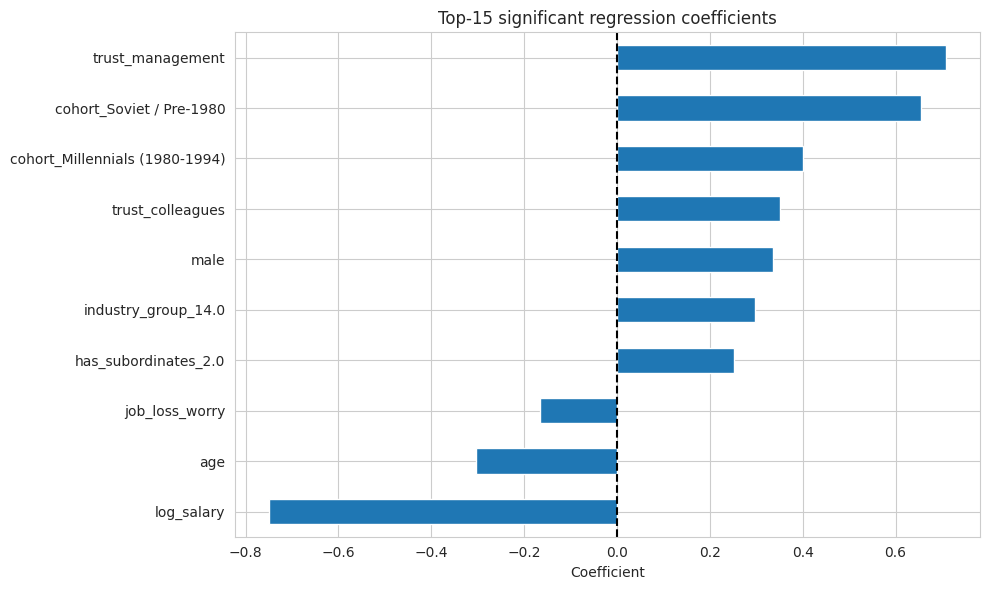

In [94]:
# Block 18. extended ordinal regression with socio-demographic factors

import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 1. prepare data
df_reg3 = df_work.dropna(subset=['job_sat_overall']).copy()

# 2. recalculate log_salary
if 'salary_30d' in df_reg3.columns:
    df_reg3['salary_30d'] = df_reg3['salary_30d'].clip(lower=1)
    df_reg3['log_salary'] = np.log(df_reg3['salary_30d'])

# 3. categorical variables (create dummies)
cat_cols = ['has_subordinates', 'official_employment', 'cohort', 'period']
for col in cat_cols:
    if col in df_reg3.columns:
        df_reg3[col] = df_reg3[col].astype('category')

# 4. handle region: keep only regions with sufficient observations (>1000)
if 'region' in df_reg3.columns:
    # count region frequencies
    region_counts = df_reg3['region'].value_counts()
    # keep only those with >1000 observations
    top_regions = region_counts[region_counts > 1000].index.tolist()
    # collapse the rest into "Other"
    df_reg3['region_group'] = df_reg3['region'].apply(lambda x: x if x in top_regions else -1)
    df_reg3['region_group'] = df_reg3['region_group'].astype('category')
    cat_cols.append('region_group')

# 5. handle industry: group into major sectors
#    in rlms industry is a numeric code. we can use it as a category,
#    but better to group into sectors. if no grouping available, use top-10.
if 'industry' in df_reg3.columns:
    # replace missing with -1
    df_reg3['industry'] = df_reg3['industry'].fillna(-1)
    # keep top-10 industries, others -> "Other"
    industry_counts = df_reg3['industry'].value_counts()
    top_industries = industry_counts[industry_counts > 500].index.tolist()
    df_reg3['industry_group'] = df_reg3['industry'].apply(lambda x: x if x in top_industries else -1)
    df_reg3['industry_group'] = df_reg3['industry_group'].astype('category')
    cat_cols.append('industry_group')

# 6. handle occupation (occupation_isco) – similarly
if 'occupation_isco' in df_reg3.columns:
    df_reg3['occupation_isco'] = df_reg3['occupation_isco'].fillna(-1)
    occ_counts = df_reg3['occupation_isco'].value_counts()
    top_occ = occ_counts[occ_counts > 500].index.tolist()
    df_reg3['occupation_group'] = df_reg3['occupation_isco'].apply(lambda x: x if x in top_occ else -1)
    df_reg3['occupation_group'] = df_reg3['occupation_group'].astype('category')
    cat_cols.append('occupation_group')

# 7. create dummy variables for all categorical columns
df_reg3 = pd.get_dummies(df_reg3, columns=cat_cols, drop_first=True)

# 8. firm size -> categories
if 'firm_size' in df_reg3.columns:
    df_reg3['firm_size_cat'] = pd.cut(
        df_reg3['firm_size'],
        bins=[0, 10, 50, 200, 10000],
        labels=['<10', '10-50', '50-200', '>200']
    )
    df_reg3['firm_size_cat'] = df_reg3['firm_size_cat'].astype('category')
    df_reg3 = pd.get_dummies(df_reg3, columns=['firm_size_cat'], drop_first=True)

# 9. build feature list (numeric + all dummies)
base_features = ['log_salary', 'trust_management', 'trust_colleagues',
                 'job_loss_worry', 'find_work_confidence', 'age', 'male']

# all columns that start with dummy prefixes
dummy_prefixes = ['has_subordinates_', 'official_employment_', 'cohort_', 'period_',
                  'firm_size_cat_', 'region_group_', 'industry_group_', 'occupation_group_']
dummy_cols = [col for col in df_reg3.columns if any(col.startswith(p) for p in dummy_prefixes)]

features = base_features + dummy_cols
features = [f for f in features if f in df_reg3.columns]

# 10. extract X and y
X = df_reg3[features].copy()
y = df_reg3['job_sat_overall'].astype(int)

# 11. standardize numeric features
num_feats = ['log_salary', 'trust_management', 'trust_colleagues',
             'job_loss_worry', 'find_work_confidence', 'age']
num_feats = [f for f in num_feats if f in X.columns]
scaler = StandardScaler()
X[num_feats] = scaler.fit_transform(X[num_feats])

# 12. clean inf and nan
X = X.replace([np.inf, -np.inf], np.nan)
before = len(X)
X = X.dropna()
after = len(X)
if before > after:
    print(f"Dropped {before - after} rows with missing values or inf.")
y = y.loc[X.index]

# 13. convert to float64
X = X.astype(float)

# 14. drop constant columns
X = X.loc[:, (X.std() > 0)]

# 15. check
print(f"X shape: {X.shape}, y shape: {y.shape}")
print("Data types in X:\n", X.dtypes.value_counts())

# 16. model (may take a while due to many features)
model = OrderedModel(y, X, distr='logit')
result = model.fit(method='bfgs', disp=False)
print(result.summary())

# 17. significant coefficients
pvals = result.pvalues
coefs = result.params
sig_vars = [var for var in pvals.index if pvals[var] < 0.05]
print("\n=== Significant predictors (p < 0.05) ===")
for var in sig_vars:
    print(f"{var}: coef = {coefs[var]:.4f}, p = {pvals[var]:.4f}")

# 18. plot top-15 significant coefficients (excluding threshold terms)
sig_coefs = coefs[sig_vars]
threshold_pattern = ['1/2', '2/3', '3/4', '4/5']
sig_coefs = sig_coefs.drop(index=[i for i in sig_coefs.index if any(p in i for p in threshold_pattern)], errors='ignore')
if len(sig_coefs) > 0:
    # take top-15 by absolute value
    top_sig = sig_coefs.abs().sort_values(ascending=False).head(15).index
    sig_coefs_top = sig_coefs[top_sig]
    plt.figure(figsize=(10, 6))
    sig_coefs_top.sort_values().plot(kind='barh')
    plt.axvline(0, color='black', linestyle='--')
    plt.title('Top-15 significant regression coefficients')
    plt.xlabel('Coefficient')
    plt.tight_layout()
    plt.show()
else:
    print("No significant predictors (excluding threshold terms).")

In [104]:
# Block 19. network analysis – data preparation

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.covariance import GraphicalLasso, GraphicalLassoCV
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# 1. select variables for the network
network_vars = [
    'job_sat_overall',
    'job_sat_conditions',
    'job_sat_pay',
    'job_sat_growth',
    'log_salary',
    'trust_management',
    'trust_colleagues',
    'job_loss_worry',
    'find_work_confidence'
]

# 2. data
df_net = df_work[network_vars].dropna().copy()

# 3. standardization
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_net), columns=df_net.columns)

print(f"Network data size: {df_scaled.shape}")

# 4. graphical lasso with cross-validation
model = GraphicalLassoCV(cv=5, alphas=4, tol=1e-3, max_iter=100)
model.fit(df_scaled)

precision = model.precision_
diag_inv = np.diag(1.0 / np.sqrt(np.diag(precision)))
partial_corr = -diag_inv @ precision @ diag_inv
np.fill_diagonal(partial_corr, 0)

partial_corr_df = pd.DataFrame(partial_corr, index=network_vars, columns=network_vars)
print("\nPartial correlation matrix (first 5x5):")
print(partial_corr_df.iloc[:9, :9])

# save
partial_corr_df.to_csv('partial_correlation_matrix.csv')

Network data size: (3928, 9)

Partial correlation matrix (first 5x5):
                      job_sat_overall  job_sat_conditions  job_sat_pay  \
job_sat_overall              0.000000            0.526745     0.183691   
job_sat_conditions           0.526745            0.000000     0.117139   
job_sat_pay                  0.183691            0.117139     0.000000   
job_sat_growth               0.214303            0.115377     0.253461   
log_salary                  -0.070436            0.031328    -0.201218   
trust_management             0.071132            0.092502     0.074796   
trust_colleagues             0.052278            0.013875     0.019371   
job_loss_worry              -0.003421           -0.054328    -0.010526   
find_work_confidence        -0.013279            0.000000     0.008148   

                      job_sat_growth  log_salary  trust_management  \
job_sat_overall             0.214303   -0.070436          0.071132   
job_sat_conditions          0.115377    0.031328 

Number of nodes: 9
Number of edges: 20


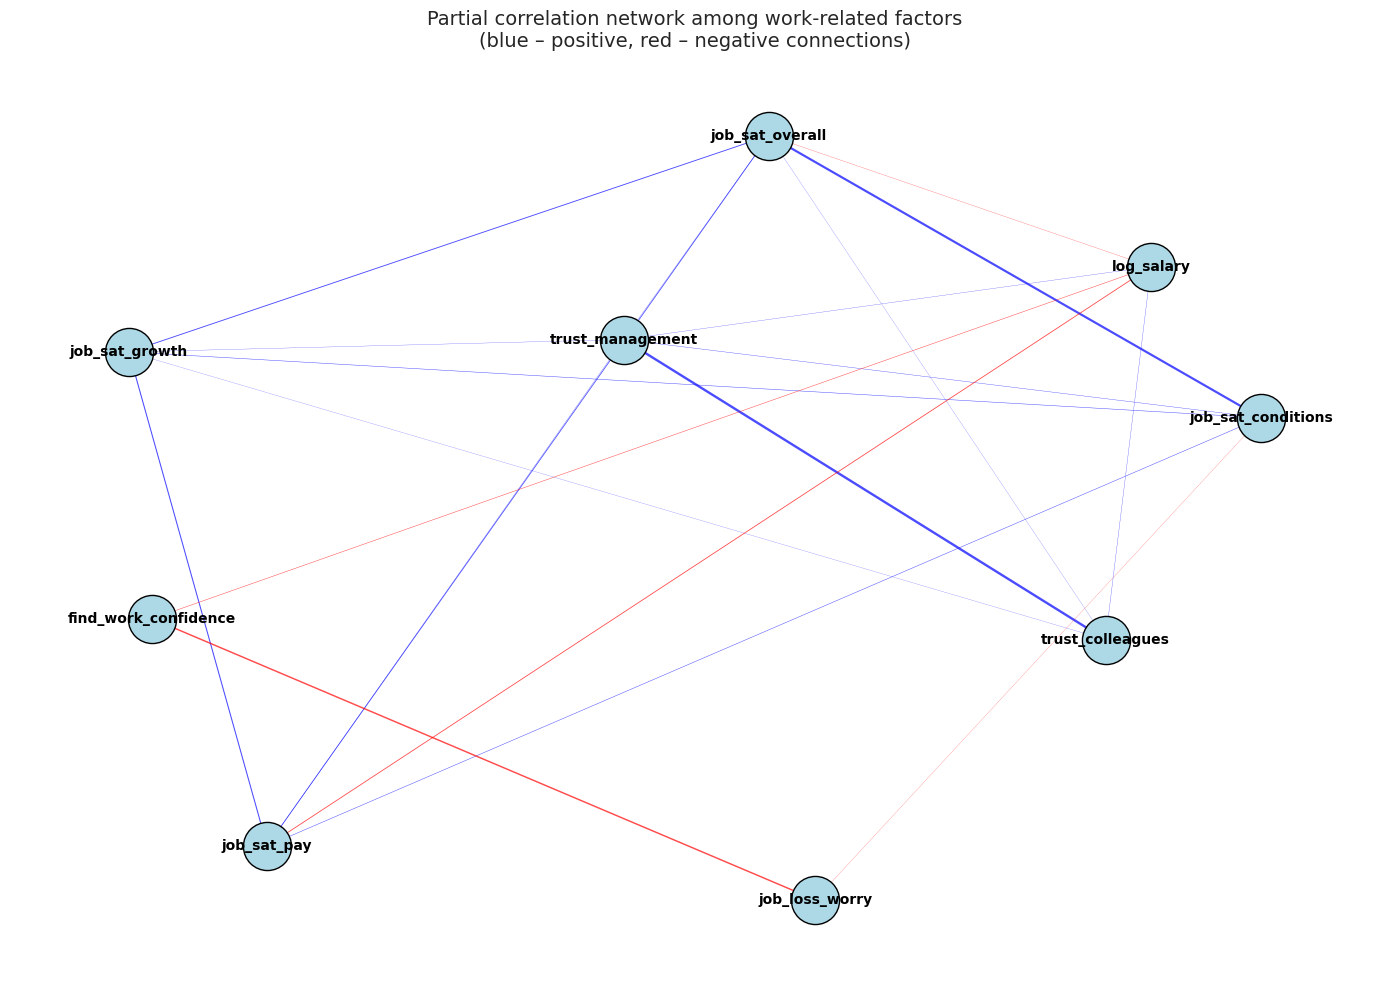

In [96]:
# Block 20. network visualization of variables

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# 1. create graph
G = nx.Graph()

# 2. add nodes
for node in network_vars:
    G.add_node(node)

# 3. add edges with weights = partial correlations
#    keep only significant connections (|corr| > 0.05)
threshold = 0.05
for i, var1 in enumerate(network_vars):
    for j, var2 in enumerate(network_vars):
        if i < j:  # avoid duplicates
            corr = partial_corr_df.iloc[i, j]
            if abs(corr) > threshold:
                G.add_edge(var1, var2, weight=corr)

print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

# 4. node positioning (fruchterman-reingold algorithm)
pos = nx.spring_layout(G, seed=42, k=1.5, iterations=50)

# 5. draw the network
plt.figure(figsize=(14, 10))

# nodes
nx.draw_networkx_nodes(G, pos, node_size=1200, node_color='lightblue', edgecolors='black')

# edges: color and thickness based on sign and strength of correlation
edges = G.edges(data=True)
positive_edges = [(u, v) for u, v, d in edges if d['weight'] > 0]
negative_edges = [(u, v) for u, v, d in edges if d['weight'] < 0]

# positive – blue, negative – red
nx.draw_networkx_edges(G, pos, edgelist=positive_edges, edge_color='blue', alpha=0.7, width=[abs(d['weight'])*3 for (u,v,d) in G.edges(data=True) if d['weight'] > 0])
nx.draw_networkx_edges(G, pos, edgelist=negative_edges, edge_color='red', alpha=0.7, width=[abs(d['weight'])*3 for (u,v,d) in G.edges(data=True) if d['weight'] < 0])

# labels
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

plt.title('Partial correlation network among work-related factors\n(blue – positive, red – negative connections)', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()


=== Node centrality ===
                      Degree  Closeness  Betweenness
job_sat_overall        0.750      0.800        0.058
trust_management       0.750      0.800        0.058
job_sat_conditions     0.625      0.727        0.177
job_sat_growth         0.625      0.667        0.030
job_sat_pay            0.625      0.727        0.028
log_salary             0.625      0.727        0.189
trust_colleagues       0.500      0.615        0.016
job_loss_worry         0.250      0.533        0.043
find_work_confidence   0.250      0.533        0.045


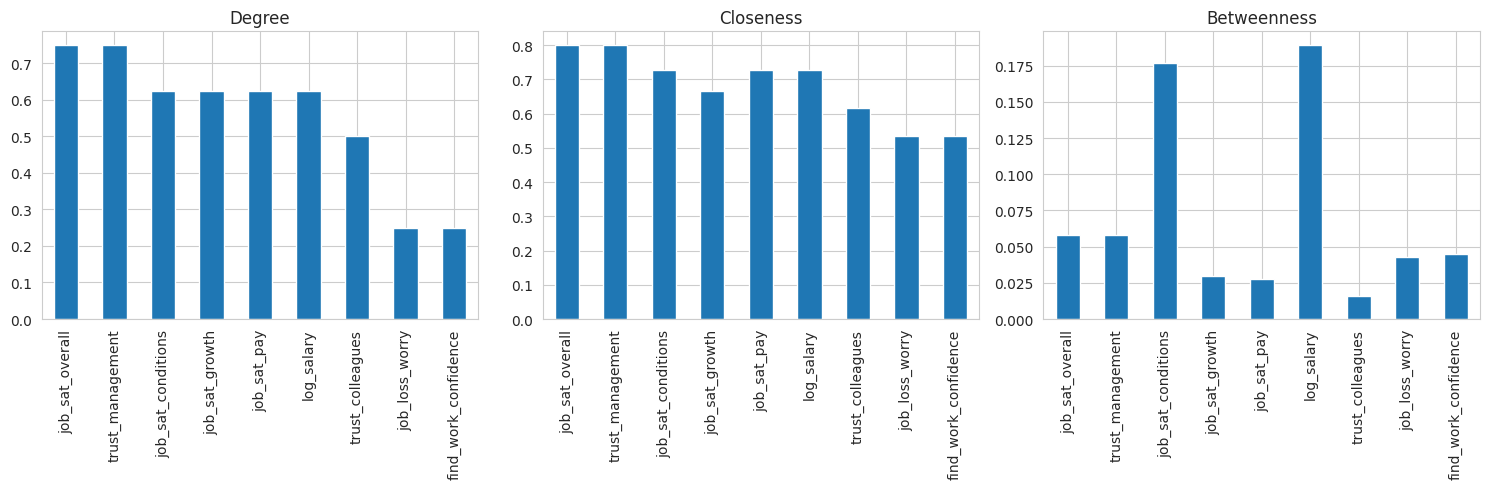

In [97]:
# Block 21. node centrality

# 1. degree (number of connections)
degree = nx.degree_centrality(G)
# 2. closeness
closeness = nx.closeness_centrality(G)
# 3. betweenness
betweenness = nx.betweenness_centrality(G)

# 4. collect in a dataframe
centrality_df = pd.DataFrame({
    'Degree': degree,
    'Closeness': closeness,
    'Betweenness': betweenness
}).sort_values('Degree', ascending=False)

print("\n=== Node centrality ===")
print(centrality_df.round(3))

# 5. visualize centrality
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
centrality_df[['Degree']].plot(kind='bar', ax=axes[0], legend=False)
axes[0].set_title('Degree')
centrality_df[['Closeness']].plot(kind='bar', ax=axes[1], legend=False)
axes[1].set_title('Closeness')
centrality_df[['Betweenness']].plot(kind='bar', ax=axes[2], legend=False)
axes[2].set_title('Betweenness')
plt.tight_layout()
plt.show()

Generations: ['Soviet / Pre-1980', 'Millennials (1980-1994)', 'Gen Z (1995+)']
Categories (3, object): ['Gen Z (1995+)', 'Millennials (1980-1994)', 'Soviet / Pre-1980']


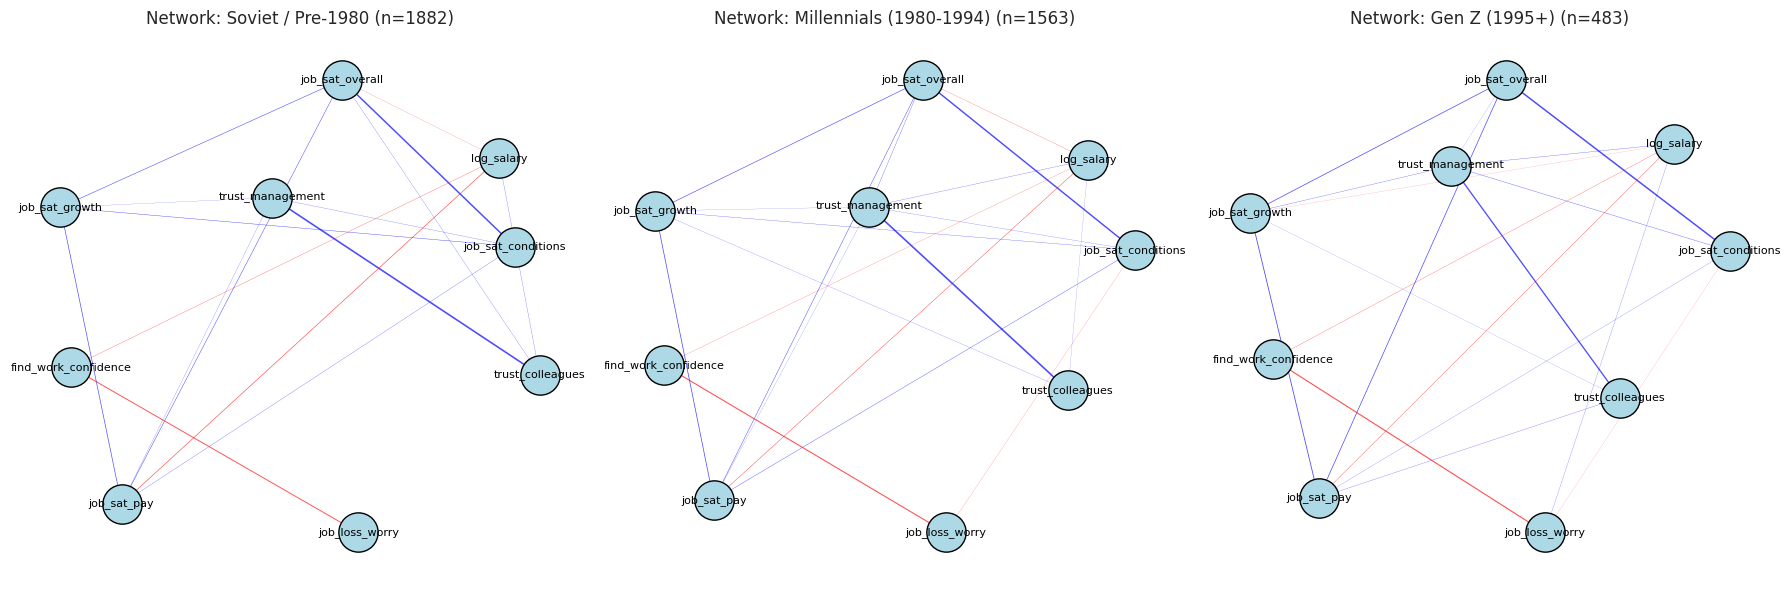

In [98]:
# Block 22. comparison of generation networks

# 1. define generations
cohorts = df_work['cohort'].dropna().unique()
print("Generations:", cohorts)

# 2. for each generation build a network and visualize
fig, axes = plt.subplots(1, len(cohorts), figsize=(6*len(cohorts), 6))
if len(cohorts) == 1:
    axes = [axes]

for idx, cohort in enumerate(cohorts):
    # subset
    df_cohort = df_work[df_work['cohort'] == cohort][network_vars].dropna()
    if len(df_cohort) < 50:
        print(f"Generation {cohort}: too few data ({len(df_cohort)})")
        continue

    # standardization
    scaler = StandardScaler()
    df_scaled_cohort = pd.DataFrame(scaler.fit_transform(df_cohort), columns=network_vars)

    # graphical lasso
    model = GraphicalLassoCV(cv=5, alphas=4, max_iter=100)
    model.fit(df_scaled_cohort)
    precision = model.precision_
    diag_inv = np.diag(1.0 / np.sqrt(np.diag(precision)))
    partial_corr = -diag_inv @ precision @ diag_inv
    np.fill_diagonal(partial_corr, 0)

    # build graph
    G_cohort = nx.Graph()
    for node in network_vars:
        G_cohort.add_node(node)
    for i, var1 in enumerate(network_vars):
        for j, var2 in enumerate(network_vars):
            if i < j:
                corr = partial_corr[i, j]
                if abs(corr) > 0.05:
                    G_cohort.add_edge(var1, var2, weight=corr)

    # visualize
    pos = nx.spring_layout(G_cohort, seed=42, k=1.5)
    ax = axes[idx]
    nx.draw_networkx_nodes(G_cohort, pos, ax=ax, node_size=800, node_color='lightblue', edgecolors='black')
    positive_edges = [(u, v) for u, v, d in G_cohort.edges(data=True) if d['weight'] > 0]
    negative_edges = [(u, v) for u, v, d in G_cohort.edges(data=True) if d['weight'] < 0]
    nx.draw_networkx_edges(G_cohort, pos, ax=ax, edgelist=positive_edges, edge_color='blue', alpha=0.7, width=[abs(d['weight'])*2 for (u,v,d) in G_cohort.edges(data=True) if d['weight'] > 0])
    nx.draw_networkx_edges(G_cohort, pos, ax=ax, edgelist=negative_edges, edge_color='red', alpha=0.7, width=[abs(d['weight'])*2 for (u,v,d) in G_cohort.edges(data=True) if d['weight'] < 0])
    nx.draw_networkx_labels(G_cohort, pos, ax=ax, font_size=8)
    ax.set_title(f'Network: {cohort} (n={len(df_cohort)})')
    ax.axis('off')

plt.tight_layout()
plt.show()

Clustering data size: (3928, 11)


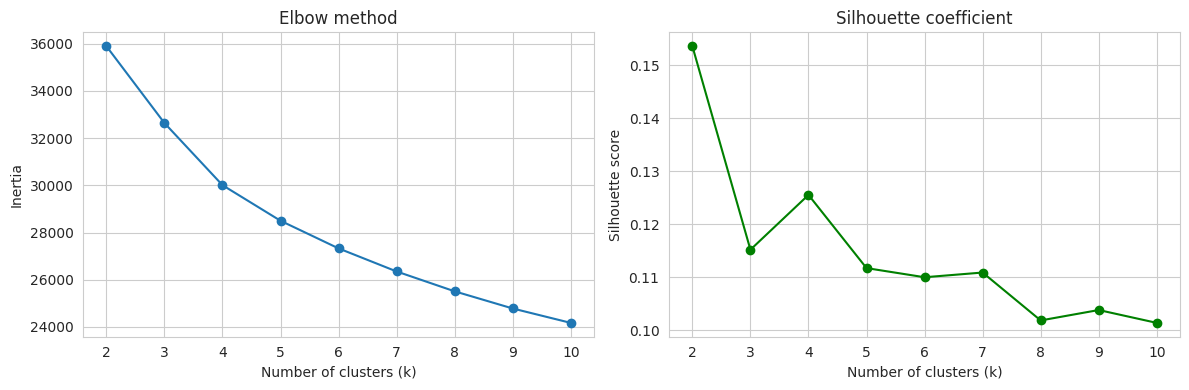

Optimal number of clusters by silhouette: 2


In [99]:
# Block 23. employee clustering – data preparation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# 1. select variables for clustering (reflecting work attitudes and demographics)
cluster_vars = [
    'job_sat_overall',      # overall satisfaction
    'job_sat_conditions',   # conditions
    'job_sat_pay',          # pay
    'job_sat_growth',       # growth
    'log_salary',           # log salary
    'trust_management',     # trust in management
    'trust_colleagues',     # trust in colleagues
    'job_loss_worry',       # fear of job loss
    'find_work_confidence', # confidence in finding a job
    'age',                  # age
    'male'                  # gender (0/1)
]

# 2. take complete-case data
df_clust = df_work[cluster_vars].dropna().copy()
print(f"Clustering data size: {df_clust.shape}")

# 3. standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clust)

# 4. determine optimal number of clusters (elbow method and silhouette)
inertias = []
silhouette_scores = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# 5. visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, marker='o')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow method')
axes[1].plot(K_range, silhouette_scores, marker='o', color='green')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette coefficient')
plt.tight_layout()
plt.show()

# 6. choose k (e.g., by maximum silhouette)
best_k = K_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters by silhouette: {best_k}")

# 7. clustering with chosen k
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_clust['cluster'] = kmeans.fit_predict(X_scaled)

# 8. add cluster labels to the main dataframe (for further analysis)
df_work['cluster'] = np.nan
df_work.loc[df_clust.index, 'cluster'] = df_clust['cluster'].astype(int)

=== Mean values by cluster ===
         job_sat_overall  job_sat_conditions  job_sat_pay  job_sat_growth  \
cluster                                                                     
0                   1.68                1.69         2.15            1.86   
1                   2.51                2.53         3.55            3.00   

         log_salary  trust_management  trust_colleagues  job_loss_worry  \
cluster                                                                   
0             10.66              1.67              1.63            2.76   
1             10.55              2.45              2.24            2.68   

         find_work_confidence    age  male  
cluster                                     
0                        2.77  44.16  0.45  
1                        2.82  44.40  0.48  

=== Cluster sizes ===
cluster
0    2334
1    1594
Name: count, dtype: int64


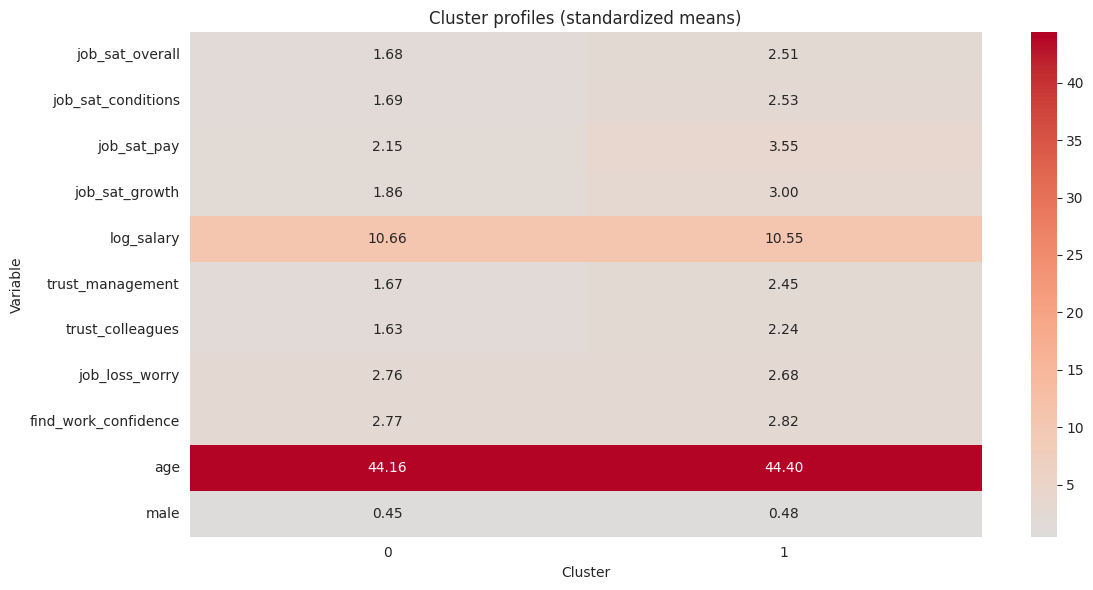

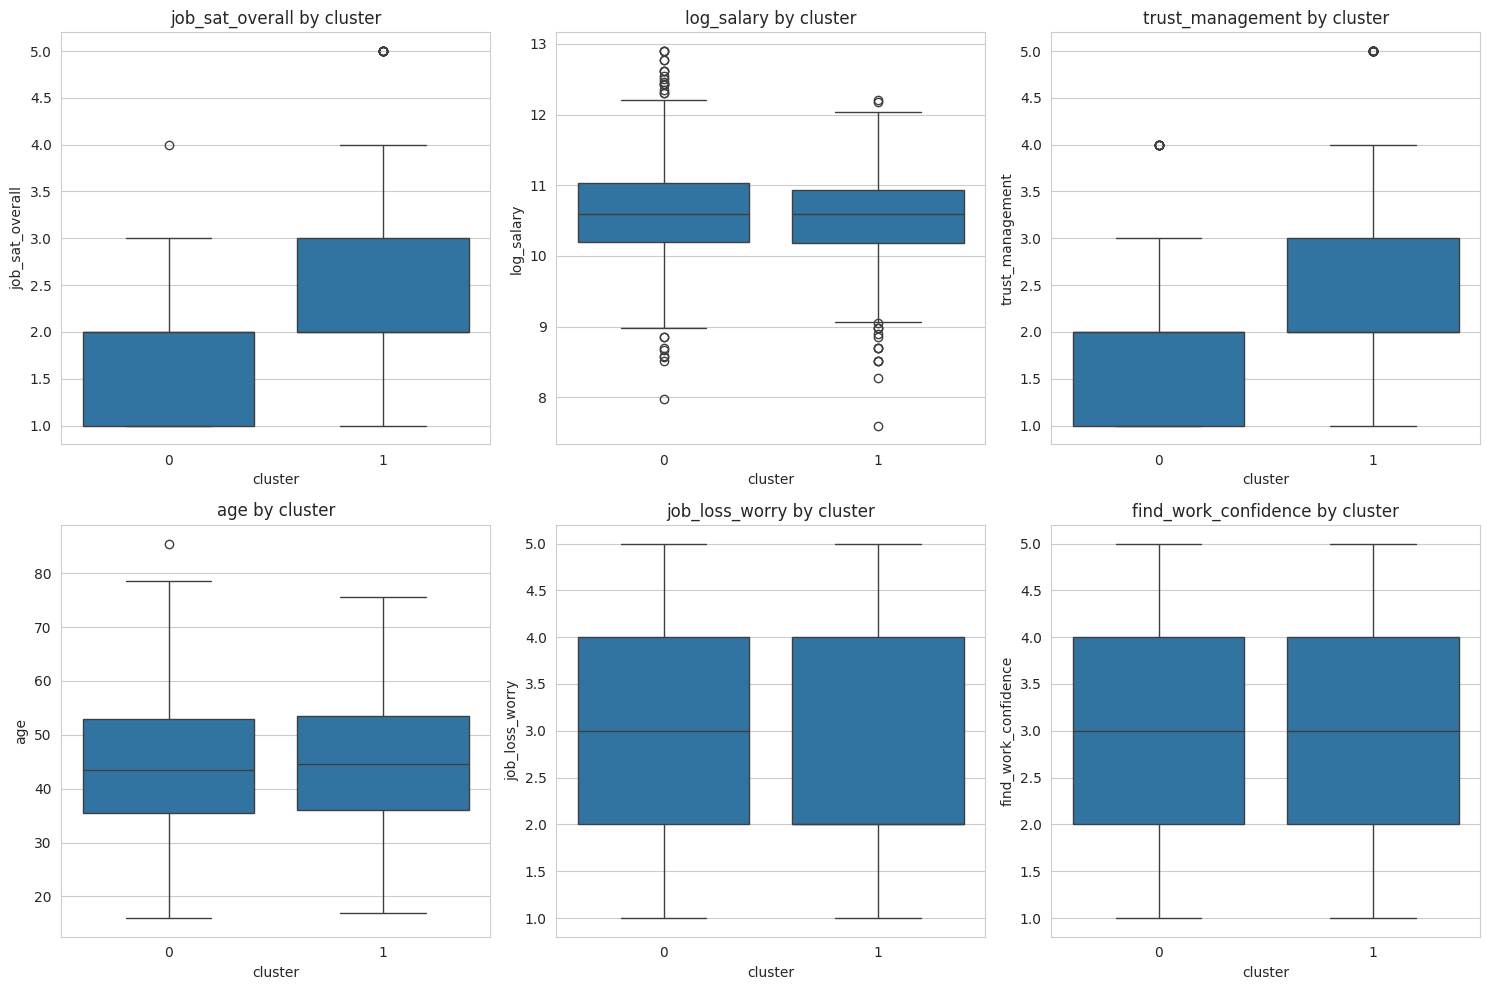

In [100]:
# Block 24. cluster profiles

# 1. mean values of variables by cluster
cluster_profiles = df_clust.groupby('cluster').mean().round(2)
print("=== Mean values by cluster ===")
print(cluster_profiles)

# 2. size of each cluster
cluster_sizes = df_clust['cluster'].value_counts().sort_index()
print("\n=== Cluster sizes ===")
print(cluster_sizes)

# 3. visualize profiles (heatmap)
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profiles.T, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Cluster profiles (standardized means)')
plt.xlabel('Cluster')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

# 4. compare clusters by key variables (boxplot)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, var in enumerate(['job_sat_overall', 'log_salary', 'trust_management', 'age', 'job_loss_worry', 'find_work_confidence']):
    sns.boxplot(x='cluster', y=var, data=df_clust, ax=axes[i])
    axes[i].set_title(f'{var} by cluster')
plt.tight_layout()
plt.show()

In [101]:
# Block 25. cluster interpretation

# 1. descriptive statistics for each cluster
for cluster in sorted(df_clust['cluster'].unique()):
    subset = df_clust[df_clust['cluster'] == cluster]
    print(f"\n=== Cluster {cluster} (n={len(subset)}) ===")
    print(f"Mean satisfaction: {subset['job_sat_overall'].mean():.2f}")
    print(f"Mean log salary: {subset['log_salary'].mean():.2f}")
    print(f"Mean age: {subset['age'].mean():.1f}")
    print(f"Proportion of males: {subset['male'].mean():.2f}")
    print(f"Mean trust in management: {subset['trust_management'].mean():.2f}")
    print(f"Mean fear of job loss: {subset['job_loss_worry'].mean():.2f}")

# 2. cluster labels (example – based on profiles)
#    for example:
#    - cluster 0: "highly satisfied with good salary and trust"
#    - cluster 1: "dissatisfied, low salary, low trust"
#    etc.

# 3. additionally: distribution of categorical variables across clusters
cat_vars = ['has_subordinates', 'official_employment', 'cohort', 'period']
for var in cat_vars:
    if var in df_work.columns:
        print(f"\n=== {var} by cluster ===")
        print(pd.crosstab(df_work['cluster'], df_work[var], normalize='index').round(3))


=== Cluster 0 (n=2334) ===
Mean satisfaction: 1.68
Mean log salary: 10.66
Mean age: 44.2
Proportion of males: 0.45
Mean trust in management: 1.67
Mean fear of job loss: 2.76

=== Cluster 1 (n=1594) ===
Mean satisfaction: 2.51
Mean log salary: 10.55
Mean age: 44.4
Proportion of males: 0.48
Mean trust in management: 2.45
Mean fear of job loss: 2.68

=== has_subordinates by cluster ===
has_subordinates    1.0    2.0
cluster                       
0.0               0.196  0.804
1.0               0.130  0.870

=== official_employment by cluster ===
official_employment    1.0    2.0
cluster                          
0.0                  0.961  0.039
1.0                  0.928  0.072

=== cohort by cluster ===
cohort   Gen Z (1995+)  Millennials (1980-1994)  Soviet / Pre-1980
cluster                                                           
0.0              0.125                    0.406              0.469
1.0              0.120                    0.386              0.494

=== period by clu

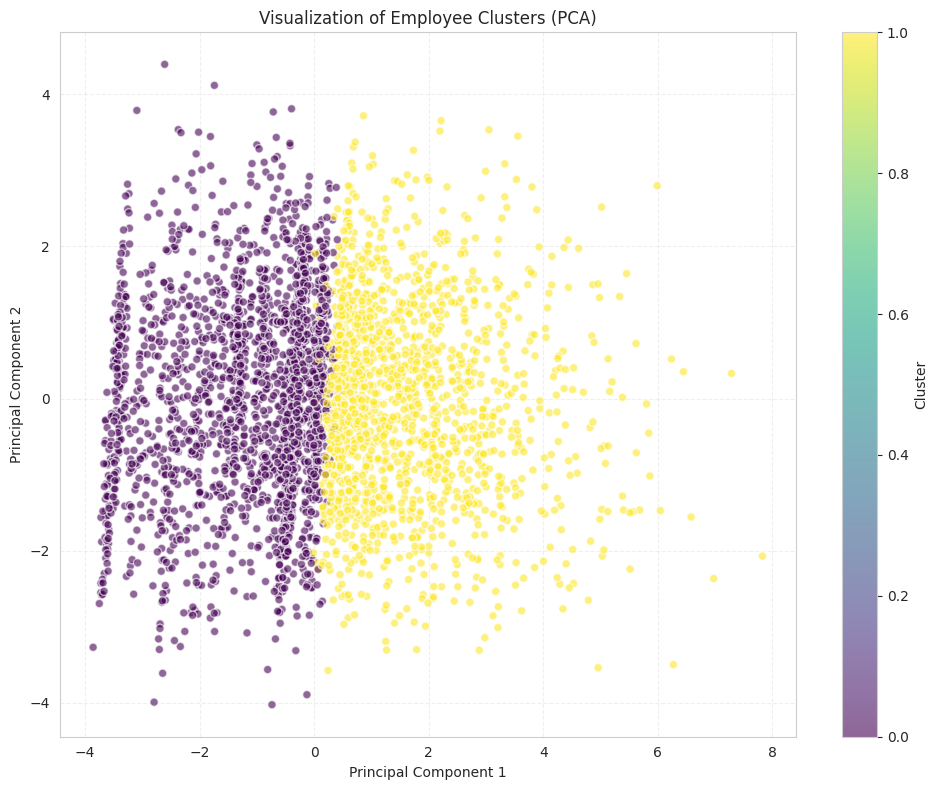

In [102]:
# Block 26. visualization of clusters in 2d (pca)

# 1. pca for dimensionality reduction
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 2. add coordinates to the dataframe
df_clust['pca1'] = X_pca[:, 0]
df_clust['pca2'] = X_pca[:, 1]

# 3. plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df_clust['pca1'], df_clust['pca2'], c=df_clust['cluster'], cmap='viridis', alpha=0.6, edgecolors='w')
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Visualization of Employee Clusters (PCA)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

R^2 on test: 0.204
RMSE: 0.662
R^2 (cross-val): 0.205 (+/- 0.042)


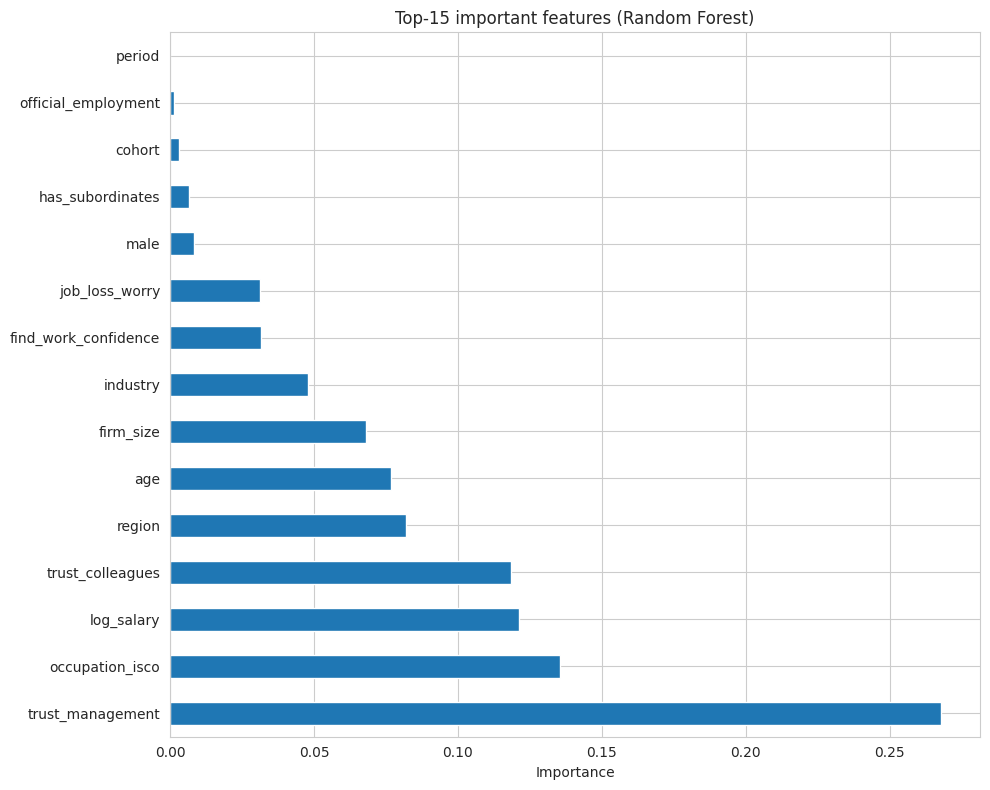

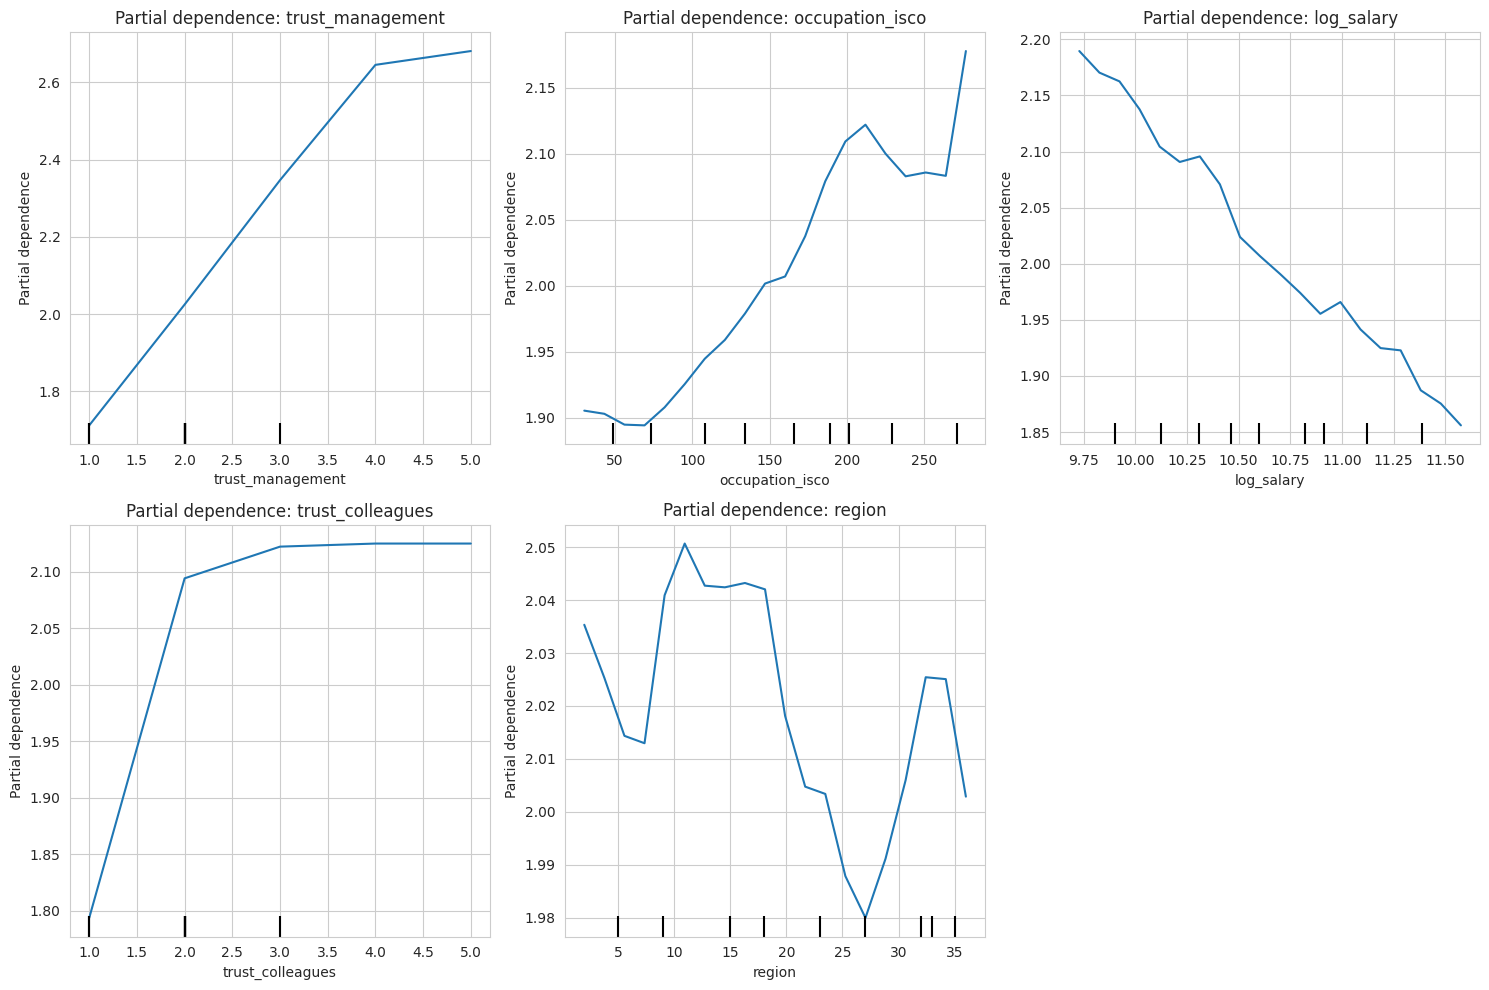

In [103]:
# Block 27. random forest for predicting satisfaction (fixed)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# 1. prepare data – use df_model (contains region and all variables)
# define the list of potential features (those present in df_model)
potential_features = [
    'log_salary', 'trust_management', 'trust_colleagues',
    'job_loss_worry', 'find_work_confidence', 'age', 'male',
    'has_subordinates', 'official_employment', 'firm_size',
    'cohort', 'period', 'industry', 'occupation_isco', 'region'
]

# keep only those that actually exist in df_model
features = [col for col in potential_features if col in df_model.columns]

# add the target variable
df_rf = df_model[features + ['job_sat_overall']].dropna().copy()

# encode categorical variables (if present)
cat_cols = ['has_subordinates', 'official_employment', 'cohort', 'period', 'industry', 'occupation_isco', 'region']
for col in cat_cols:
    if col in df_rf.columns:
        df_rf[col] = df_rf[col].astype('category')
        df_rf[col] = df_rf[col].cat.codes

# 2. split into x and y
X = df_rf.drop('job_sat_overall', axis=1)
y = df_rf['job_sat_overall']

# 3. train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 4. random forest model
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# 5. evaluation
y_pred = rf.predict(X_test)
print(f"R^2 on test: {r2_score(y_test, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")

# cross-validation
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')
print(f"R^2 (cross-val): {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

# 6. feature importance
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
feat_imp.head(15).plot(kind='barh')
plt.title('Top-15 important features (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# 7. partial dependence plots (to check non-linearities)
top_features = feat_imp.head(5).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, feature in enumerate(top_features):
    if i < len(axes):
        PartialDependenceDisplay.from_estimator(
            rf, X_train, [feature], ax=axes[i], grid_resolution=20
        )
        axes[i].set_title(f'Partial dependence: {feature}')
# remove empty subplots
for j in range(len(top_features), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()